# Diabetic Retinopathy Stage Detection - Training Notebook

This notebook builds a diabetic retinopathy (DR) screening model from retinal fundus photographs. It grades each image on the five-stage scale (No DR, Mild, Moderate, Severe, Proliferative), detects whether DR is present, checks whether the photo is good enough to grade, and reports how certain it is.



## 0. Setup

Install the extra packages, import libraries, create output folders, check the GPU, fix the random seed and define every setting in one place.

### 0.1 Install packages
`timm` provides the pretrained CNN; `onnx` and `onnxruntime` are used for the deployment export.

In [1]:
!pip install -q timm onnx onnxruntime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.6/23.6 MB 77.9 MB/s eta 0:00:00


### 0.2 Imports and output folders
All figures, tables and logs are written under `/kaggle/working/results` so they can be downloaded for the report.

In [2]:
import os, json, time, random, copy, zipfile, inspect, warnings
from pathlib import Path
from dataclasses import dataclass, asdict
from concurrent.futures import ThreadPoolExecutor

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import timm
from tqdm.auto import tqdm

warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

WORKING_DIR = Path('/kaggle/working')
WORKING_DIR.mkdir(parents=True, exist_ok=True)
os.chdir(WORKING_DIR)
for folder in ['results/figures', 'results/tables', 'results/logs', 'models/export']:
    Path(folder).mkdir(parents=True, exist_ok=True)


def show_table(title, table):
    # print a table as plain text
    print(f'\n=== {title} ===')
    print(table.to_string())


def save_figure(path, dpi=200):

    plt.tight_layout()
    plt.savefig(path, dpi=dpi)
    print(f'figure saved: {path}')
    plt.show()


print('torch version:', torch.__version__)
print('timm version :', timm.__version__)

torch version: 2.10.0+cu128
timm version : 1.0.26


### 0.3 Check the GPU
Training needs a GPU accelerator (P100 or T4).

In [3]:
if torch.cuda.is_available():
    gpu = torch.cuda.get_device_properties(0)
    print(f'GPU: {gpu.name} | memory: {gpu.total_memory / 1e9:.1f} GB')
else:
    print('GPU: NONE - turn on the accelerator in the notebook settings')

GPU: Tesla T4 | memory: 15.6 GB


### 0.4 Fix the random seed
The same seed gives the same splits, sampling and initial weights on every run.

In [4]:
RANDOM_SEED = 42

def seed_everything(seed=RANDOM_SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = True

seed_everything()
print('random seed:', RANDOM_SEED)

random seed: 42


### 0.5 Configuration
Every hyperparameter is stored in one `config` object. It is saved inside each checkpoint and with the final results, so every number can be traced back to the settings that produced it.

In [5]:
@dataclass
class Config:
    # data
    image_size: int = 384              # input resolution in pixels
    num_classes: int = 5               # DR stages 0-4
    num_quality_classes: int = 2       # gradable / ungradable
    val_frac: float = 0.15
    test_frac: float = 0.15
    seed: int = 42

    # preprocessing switches
    use_graham: bool = True            # illumination correction / edge enhancement
    use_clahe: bool = True             # contrast enhancement

    # model
    backbone: str = 'tf_efficientnetv2_s.in21k_ft_in1k'
    pretrained: bool = True            # start from ImageNet weights
    dropout: float = 0.4

    # optimisation
    epochs: int = 25
    batch_size: int = 32
    head_lr: float = 1e-3              # learning rate for the new output layers
    backbone_lr: float = 1e-4          # learning rate for the pretrained layers
    weight_decay: float = 1e-5
    warmup_steps: int = 300
    grad_clip: float = 1.0
    amp: bool = True                   # mixed precision
    use_ema: bool = True               # moving average of weights
    ema_decay: float = 0.999
    freeze_first_epoch: bool = True    # train heads only in epoch 0
    quality_loss_weight: float = 0.3
    label_smoothing: float = 0.05

    # class balancing
    sampler_beta: float = 0.999

    # early stopping
    patience: int = 4
    min_delta: float = 0.002

    # uncertainty
    mc_dropout_samples: int = 20

    # triage thresholds
    ungradable_threshold: float = 0.50
    uncertainty_threshold: float = 0.45
    confidence_threshold: float = 0.55

    # paths and hardware
    checkpoint_dir: str = '/kaggle/working/checkpoints'
    cache_dir: str = '/kaggle/working/cache'
    device: str = 'cuda'
    num_workers: int = 2

    def to_dict(self):
        return asdict(self)


config = Config()
config.device = 'cuda' if torch.cuda.is_available() else 'cpu'
config.amp = config.amp and config.device == 'cuda'
config.num_workers = min(4, os.cpu_count() or 2)

show_table('Configuration', pd.Series(config.to_dict()).to_frame('value'))


=== Configuration ===
                                                   value
image_size                                           384
num_classes                                            5
num_quality_classes                                    2
val_frac                                            0.15
test_frac                                           0.15
seed                                                  42
use_graham                                          True
use_clahe                                           True
backbone               tf_efficientnetv2_s.in21k_ft_in1k
pretrained                                          True
dropout                                              0.4
epochs                                                25
batch_size                                            32
head_lr                                            0.001
backbone_lr                                       0.0001
weight_decay                                     0.00001
warmup_s

## 1. Dataset

**DDR** (13,673 fundus images from 147 hospitals, graded 0-4 plus an "ungradable" class 5) is used for training, validation and internal testing. **APTOS 2019** (3,662 images from India, different cameras and population) is never trained on and is used only as an external test set.

Tasks: locate both datasets, build one table of all images, and analyse the class distribution, the ungradable images, the split composition and the image sizes.

### 1.1 Find the attached datasets

In [6]:
!ls /kaggle/input/

competitions  datasets


In [7]:
def find_dataset_folder(is_match, root='/kaggle/input', max_depth=4):
    root = Path(root)
    if not root.exists():
        return None
    for folder_path, subfolders, files in os.walk(root):
        folder = Path(folder_path)
        depth = len(folder.relative_to(root).parts)
        if depth >= max_depth:
            subfolders[:] = []
        if depth > 0 and is_match(folder, subfolders, files):
            return str(folder)
    return None


DDR_FOLDER = find_dataset_folder(lambda folder, subfolders, files: 'ddr' in folder.name.lower())
APTOS_FOLDER = find_dataset_folder(lambda folder, subfolders, files:
                                   'train.csv' in files and 'train_images' in subfolders)

# set by hand if the wrong folder is picked
# DDR_FOLDER = '/kaggle/input/ddrdataset'
# APTOS_FOLDER = '/kaggle/input/aptos2019-blindness-detection'

print('DDR folder  :', DDR_FOLDER)
print('APTOS folder:', APTOS_FOLDER)
assert DDR_FOLDER and APTOS_FOLDER, 'dataset not found - attach both datasets with Add Data'

DDR folder  : /kaggle/input/datasets/mariaherrerot/ddrdataset
APTOS folder: /kaggle/input/competitions/aptos2019-blindness-detection


### 1.2 Inspect the DDR folder layout
Different Kaggle copies of DDR store their labels differently, so the folder tree is printed before loading.

In [8]:
def print_folder_tree(root, max_depth=3):
    root = Path(root)
    if not root.exists():
        print('PATH DOES NOT EXIST:', root)
        return
    for path in sorted(root.rglob('*'))[:400]:
        depth = len(path.relative_to(root).parts)
        if depth > max_depth:
            continue
        indent = '  ' * (depth - 1)
        if path.is_dir():
            print(f'{indent}{path.name}/  ({sum(1 for _ in path.iterdir())} entries)')
        elif depth <= 2 or path.suffix in {'.csv', '.txt'}:
            print(f'{indent}{path.name}')


print_folder_tree(DDR_FOLDER)

DR_grading/  (1 entries)
  DR_grading/  (12524 entries)


### 1.3 DDR loader
Reads the grading labels (official `train/valid/test` lists, a single CSV, or one folder per class), matches every label to its image file and assigns train / validation / test splits. If the copy has no official split, a stratified 70 / 15 / 15 split is created.

Ungradable images (label 5) are **kept**: they get grade `-1` (left out of the grading loss) and quality `1`, so they can teach the quality head to reject bad photos.

In [9]:
UNGRADABLE_LABEL = 5
GRADE_NAMES = {0: 'No DR', 1: 'Mild NPDR', 2: 'Moderate NPDR',
               3: 'Severe NPDR', 4: 'Proliferative DR'}
LABEL_NAMES = {**GRADE_NAMES, 5: 'Ungradable'}


def read_label_file(path):
    # txt: "<file> <label>" per line | csv: name and label columns
    path = Path(path)
    if path.suffix.lower() == '.csv':
        table = pd.read_csv(path)
        table.columns = [c.strip().lower() for c in table.columns]
        name_column = next((c for c in table.columns if c in
                            {'image', 'id_code', 'filename', 'name', 'image_name', 'img'}),
                           table.columns[0])
        label_column = next((c for c in table.columns if c in
                             {'label', 'level', 'grade', 'diagnosis', 'dr_grade', 'class'}),
                            table.columns[-1])
        return pd.DataFrame({'filename': table[name_column].astype(str),
                             'raw_label': table[label_column].astype(int)})
    rows = []
    for line in path.read_text().strip().splitlines():
        parts = line.strip().split()
        if len(parts) >= 2:
            rows.append({'filename': parts[0], 'raw_label': int(parts[1])})
    return pd.DataFrame(rows)


def index_image_files(root):
    # file name (and name without extension) -> path relative to root
    index = {}
    for extension in ('*.jpg', '*.jpeg', '*.png', '*.JPG', '*.JPEG', '*.PNG'):
        for path in Path(root).rglob(extension):
            relative_path = str(path.relative_to(root))
            index.setdefault(path.name, relative_path)
            index.setdefault(path.stem, relative_path)
    return index


def make_stratified_split(table, val_frac=0.15, test_frac=0.15, seed=42):
    from sklearn.model_selection import train_test_split

    def safe_strata(labels):
        # merge classes too small to stratify
        counts = labels.value_counts()
        rare = set(counts[counts < 2].index)
        merged = labels.where(~labels.isin(rare), -99)
        return None if merged.value_counts().min() < 2 else merged

    train_index, holdout_index = train_test_split(
        table.index, test_size=val_frac + test_frac, random_state=seed,
        stratify=safe_strata(table['raw_label']))
    val_index, test_index = train_test_split(
        holdout_index, test_size=test_frac / (val_frac + test_frac), random_state=seed,
        stratify=safe_strata(table.loc[holdout_index, 'raw_label']))

    table = table.copy()
    table['split'] = 'train'
    table.loc[val_index, 'split'] = 'val'
    table.loc[test_index, 'split'] = 'test'
    return table


def load_ddr(root):
    root = Path(root)
    image_index = index_image_files(root)
    if not image_index:
        raise FileNotFoundError(f'no images found under {root}')

    # layout A: official train / valid / test label files
    split_files = {'train': ['train.txt', 'train.csv'],
                   'val': ['valid.txt', 'val.txt', 'valid.csv', 'val.csv'],
                   'test': ['test.txt', 'test.csv']}
    found_files = {}
    for split, names in split_files.items():
        for name in names:
            matches = list(root.rglob(name))
            if matches:
                found_files[split] = matches[0]
                break

    split_source = 'official'
    if len(found_files) >= 2:
        parts = []
        for split, path in found_files.items():
            part = read_label_file(path)
            part['split'] = split
            parts.append(part)
        table = pd.concat(parts, ignore_index=True)
    else:
        split_source = 'generated'
        # layout B: one grading csv
        label_csvs = [p for p in root.rglob('*.csv')
                      if 'grading' in p.name.lower() or 'label' in p.name.lower()]
        if label_csvs:
            table = read_label_file(label_csvs[0])
        else:
            # layout C: one folder per class
            rows = []
            for class_folder in sorted(root.rglob('*')):
                if class_folder.is_dir() and class_folder.name.isdigit():
                    for image_file in class_folder.iterdir():
                        if image_file.suffix.lower() in {'.jpg', '.jpeg', '.png'}:
                            rows.append({'filename': image_file.name,
                                         'raw_label': int(class_folder.name)})
            if not rows:
                raise RuntimeError('unknown DDR layout - check the folder tree above')
            table = pd.DataFrame(rows)
        table = make_stratified_split(table, config.val_frac, config.test_frac, config.seed)

    # match labels to real files
    table['image'] = table['filename'].map(
        lambda name: image_index.get(name) or image_index.get(Path(name).name)
        or image_index.get(Path(name).stem))
    missing_count = int(table['image'].isna().sum())
    if missing_count:
        print(f'[DDR] {missing_count} listed images not found on disk - dropped')
    table = table.dropna(subset=['image']).reset_index(drop=True)

    # keep ungradable images: grade -1, quality 1
    table['ungradable'] = table['raw_label'] == UNGRADABLE_LABEL
    table['quality'] = table['ungradable'].astype(int)
    table['level'] = table['raw_label'].where(~table['ungradable'], -1).astype(int)
    table['source'] = 'DDR'
    table['split_source'] = split_source
    return table[['image', 'level', 'quality', 'split', 'ungradable', 'source',
                  'split_source', 'raw_label']]

In [10]:
ddr_images = load_ddr(DDR_FOLDER)

print(f'DDR images loaded : {len(ddr_images)}')
print(f'split source      : {ddr_images["split_source"].iloc[0]}')
print(f'ungradable images : {int(ddr_images["ungradable"].sum())}')
show_table('First 5 rows', ddr_images.head())

DDR images loaded : 12522
split source      : generated
ungradable images : 0

=== First 5 rows ===
                                         image  level  quality  split  ungradable source split_source  raw_label
0  DR_grading/DR_grading/20170413102628830.jpg      0        0  train       False    DDR    generated          0
1  DR_grading/DR_grading/20170413111955404.jpg      0        0   test       False    DDR    generated          0
2  DR_grading/DR_grading/20170413112015395.jpg      0        0   test       False    DDR    generated          0
3  DR_grading/DR_grading/20170413112017305.jpg      0        0   test       False    DDR    generated          0
4  DR_grading/DR_grading/20170413112528859.jpg      0        0    val       False    DDR    generated          0


### 1.4 APTOS 2019 loader (external test set)
Every APTOS image is marked `split = "external"`. It is never used for training or for choosing thresholds, so its results measure how well the model generalises to new hospitals and cameras.

In [11]:
def load_aptos(root, labels_csv='train.csv', image_folder='train_images'):
    root = Path(root)
    table = pd.read_csv(root / labels_csv)
    table.columns = [c.strip().lower() for c in table.columns]
    id_column = 'id_code' if 'id_code' in table.columns else table.columns[0]
    label_column = 'diagnosis' if 'diagnosis' in table.columns else table.columns[1]
    return pd.DataFrame({
        'image': table[id_column].astype(str).map(lambda image_id: f'{image_folder}/{image_id}.png'),
        'level': table[label_column].astype(int),
        'quality': -1,
        'split': 'external',
        'ungradable': False,
        'source': 'APTOS',
        'raw_label': table[label_column].astype(int),
    })


aptos_images = load_aptos(APTOS_FOLDER)
print(f'APTOS images loaded: {len(aptos_images)}')
show_table('First 3 rows', aptos_images.head(3))

APTOS images loaded: 3662

=== First 3 rows ===
                           image  level  quality     split  ungradable source  raw_label
0  train_images/000c1434d8d7.png      2       -1  external       False  APTOS          2
1  train_images/001639a390f0.png      4       -1  external       False  APTOS          4
2  train_images/0024cdab0c1e.png      1       -1  external       False  APTOS          1


### 1.5 Combined image table
One table listing every image from both datasets, saved as `manifest.csv`.

In [12]:
all_images = pd.concat([ddr_images, aptos_images], ignore_index=True)
all_images.to_csv('results/tables/manifest.csv', index=False)
show_table('Images per dataset and split', all_images.groupby(['source', 'split']).size().to_frame('images'))


=== Images per dataset and split ===
                 images
source split           
APTOS  external    3662
DDR    test        1879
       train       8765
       val         1878


### 1.6 Class distribution
Counts images per DR stage. The data is heavily imbalanced (most images are "No DR"), which is why class balancing is used in Section 3 and why accuracy alone is not a sufficient metric.

In [13]:
def grade_distribution_table(table):
    graded = table[~table['ungradable']]
    counts = graded['level'].value_counts().sort_index()
    result = pd.DataFrame({'grade': counts.index,
                           'name': [GRADE_NAMES[g] for g in counts.index],
                           'count': counts.values})
    result['percent'] = (result['count'] / result['count'].sum() * 100).round(2)
    result['ratio_to_majority'] = (result['count'].max() / result['count']).round(1)
    return result


def split_summary_table(table):
    graded = table[~table['ungradable']]
    summary = pd.crosstab(graded['split'], graded['level'])
    summary.columns = [f'{g} ({GRADE_NAMES[g]})' for g in summary.columns]
    summary['Gradable total'] = summary.sum(axis=1)
    summary['Ungradable'] = table[table['ungradable']].groupby('split').size()
    summary['Ungradable'] = summary['Ungradable'].fillna(0).astype(int)
    summary['All images'] = summary['Gradable total'] + summary['Ungradable']
    referable_share = (graded['level'] >= 2).groupby(graded['split']).mean()
    summary['Referable %'] = (referable_share * 100).round(1)
    return summary


grade_distribution = grade_distribution_table(ddr_images)
grade_distribution.to_csv('results/tables/table1_class_distribution.csv', index=False)
show_table('DDR grade distribution', grade_distribution)
print(f"\nimbalance ratio (largest / smallest class): {grade_distribution['ratio_to_majority'].max():.1f} : 1")


=== DDR grade distribution ===
   grade              name  count  percent  ratio_to_majority
0      0             No DR   6266    50.04                1.0
1      1         Mild NPDR    630     5.03                9.9
2      2     Moderate NPDR   4477    35.75                1.4
3      3       Severe NPDR    236     1.88               26.6
4      4  Proliferative DR    913     7.29                6.9

imbalance ratio (largest / smallest class): 26.6 : 1


figure saved: results/figures/fig2_class_distribution.png


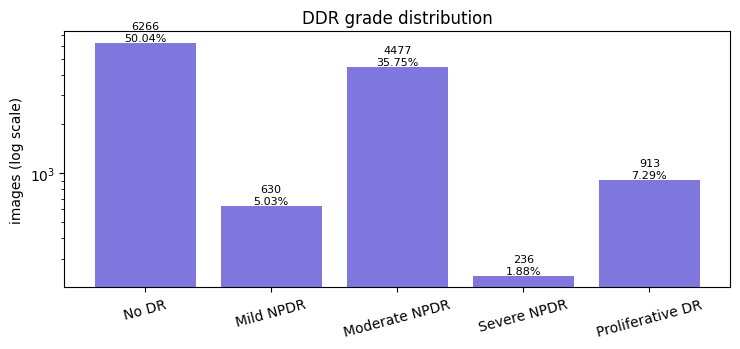

In [14]:
fig, ax = plt.subplots(figsize=(7.5, 3.6))
bars = ax.bar(grade_distribution['name'], grade_distribution['count'], color='#7F77DD', edgecolor='none')
ax.set_yscale('log')
ax.set_ylabel('images (log scale)')
ax.set_title('DDR grade distribution')
for bar, count, percent in zip(bars, grade_distribution['count'], grade_distribution['percent']):
    ax.text(bar.get_x() + bar.get_width() / 2, count, f'{count}\n{percent}%',
            ha='center', va='bottom', fontsize=8)
plt.xticks(rotation=15)
save_figure('results/figures/fig2_class_distribution.png')

### 1.7 Ungradable images
Counts the photos marked ungradable in each split. These train the quality gate that asks for a re-capture instead of giving an unreliable grade.

In [15]:
ungradable_count = int(ddr_images['ungradable'].sum())
print(f'ungradable images: {ungradable_count} / {len(ddr_images)} = {ungradable_count / len(ddr_images):.1%}')
if ungradable_count == 0:
    print('WARNING: no ungradable images in this copy of DDR - the quality head has no reject examples')
show_table('Ungradable images per split',
           ddr_images.groupby('split')['ungradable'].agg(['sum', 'mean'])
           .rename(columns={'sum': 'ungradable', 'mean': 'fraction'}))

ungradable images: 0 / 12522 = 0.0%

=== Ungradable images per split ===
       ungradable  fraction
split                      
test            0       0.0
train           0       0.0
val             0       0.0


### 1.8 Split summary
Checks that every grade appears in every split, and shows the share of referable DR (grade 2 or higher) per split.

In [16]:
split_summary = split_summary_table(all_images)
split_summary.to_csv('results/tables/table2_split_summary.csv')
show_table('Images per split and grade', split_summary)


=== Images per split and grade ===
          0 (No DR)  1 (Mild NPDR)  2 (Moderate NPDR)  3 (Severe NPDR)  4 (Proliferative DR)  Gradable total  Ungradable  All images  Referable %
split                                                                                                                                            
external       1805            370                999              193                   295            3662           0        3662         40.6
test            940             95                672               35                   137            1879           0        1879         44.9
train          4386            441               3134              165                   639            8765           0        8765         44.9
val             940             94                671               36                   137            1878           0        1878         44.9


### 1.9 Image sizes
Measures resolution and aspect ratio on a sample. Images come from many cameras, so they must be cropped and resized to one size.

In [17]:
size_rows = []
for relative_path in ddr_images.sample(min(60, len(ddr_images)), random_state=RANDOM_SEED)['image']:
    image = cv2.imread(f'{DDR_FOLDER}/{relative_path}')
    if image is not None:
        height, width = image.shape[:2]
        size_rows.append({'height': height, 'width': width,
                          'aspect_ratio': round(width / height, 3),
                          'megapixels': round(height * width / 1e6, 2)})

image_sizes = pd.DataFrame(size_rows)
print(f'{len(image_sizes)} images sampled')
show_table('Image size statistics', image_sizes.describe().round(2))

60 images sampled

=== Image size statistics ===
        height    width  aspect_ratio  megapixels
count    60.00    60.00         60.00       60.00
mean    752.32   837.65          1.05        1.01
std     541.08   740.78          0.13        1.80
min     512.00   512.00          1.00        0.26
25%     512.00   512.00          1.00        0.26
50%     512.00   512.00          1.00        0.26
75%     512.00   512.00          1.00        0.26
max    2448.00  3264.00          1.50        7.99


### 1.10 Example images per grade
Three random images for each DR stage.

figure saved: results/figures/fig3_samples_by_grade.png


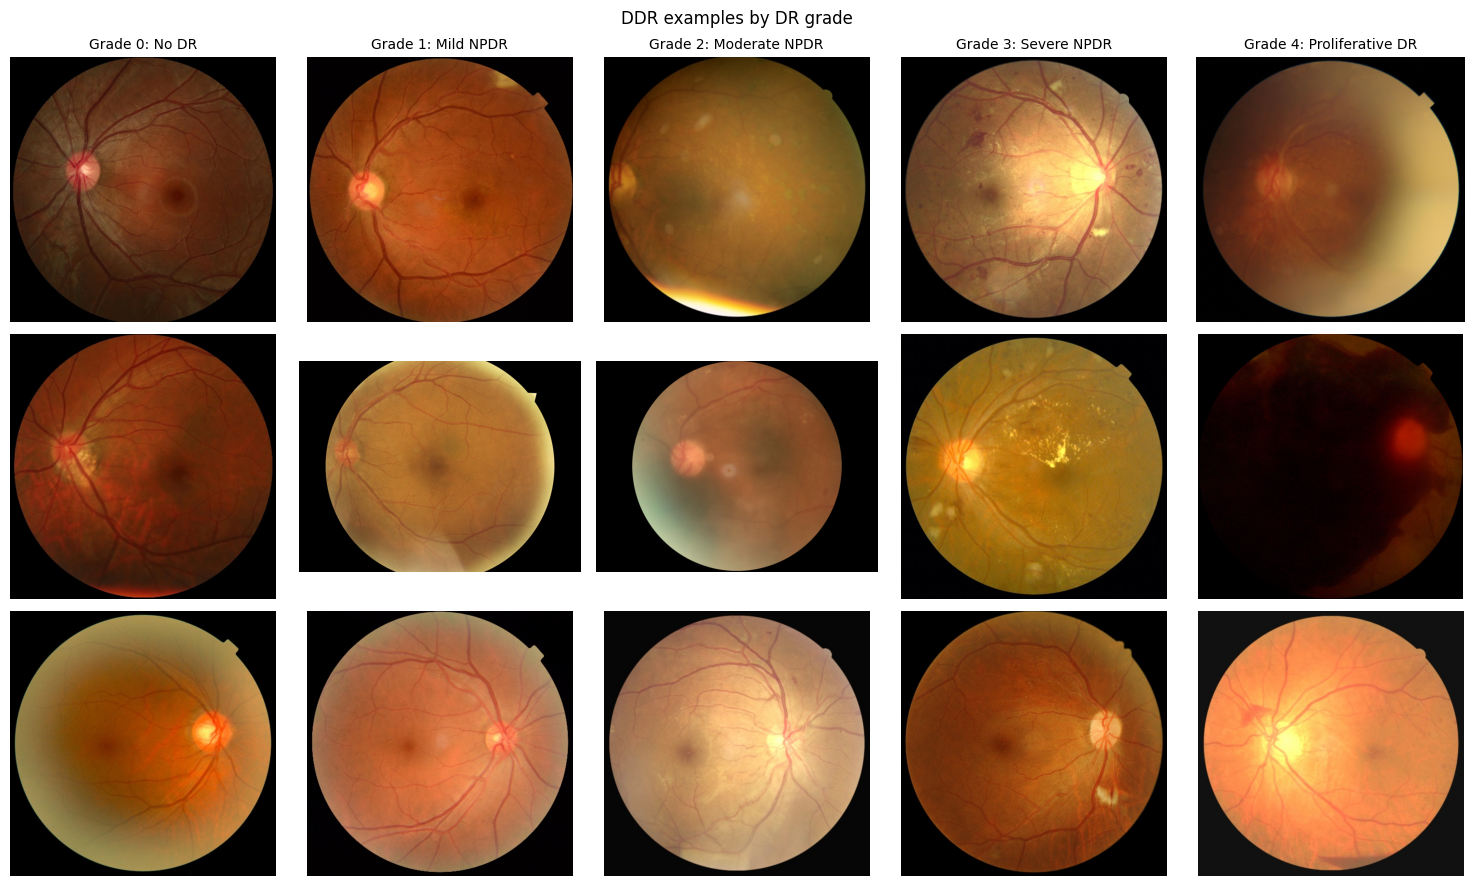

In [18]:
fig, axes = plt.subplots(3, 5, figsize=(15, 9))
for column, grade in enumerate(range(5)):
    examples = ddr_images[ddr_images['level'] == grade]
    examples = examples.sample(min(3, len(examples)), random_state=RANDOM_SEED)
    for row in range(3):
        axes[row, column].axis('off')
    for row, (_, record) in enumerate(examples.iterrows()):
        image = cv2.imread(f"{DDR_FOLDER}/{record['image']}")
        axes[row, column].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    axes[0, column].set_title(f'Grade {grade}: {GRADE_NAMES[grade]}', fontsize=10)
plt.suptitle('DDR examples by DR grade', y=0.98)
save_figure('results/figures/fig3_samples_by_grade.png', dpi=150)

### 1.11 Ungradable examples
Examples of photos too poor to grade (blur, bad exposure, poor field of view).

In [19]:
ungradable_images = ddr_images[ddr_images['ungradable']]
if len(ungradable_images) == 0:
    print('no ungradable images to show')
else:
    fig, axes = plt.subplots(1, 5, figsize=(15, 3.2))
    for ax in axes:
        ax.axis('off')
    for ax, (_, record) in zip(axes, ungradable_images.sample(min(5, len(ungradable_images)),
                                                              random_state=RANDOM_SEED).iterrows()):
        image = cv2.imread(f"{DDR_FOLDER}/{record['image']}")
        ax.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.suptitle('DDR ungradable images')
    save_figure('results/figures/fig3b_ungradable_samples.png', dpi=150)

no ungradable images to show


## 2. Preprocessing

Raw fundus photos have large black borders, uneven lighting from the camera flash, and low contrast around small lesions. The pipeline fixes each problem in turn:

1. **Crop** to the retina and **pad** to a square (no stretching of lesion shapes)
2. **Resize** to 384 x 384
3. **CLAHE** on the green channel (contrast enhancement where vessels and lesions are most visible)
4. **Illumination correction** by subtracting a blurred copy of the image - this removes slow lighting changes and sharpens edges and small lesions (edge enhancement)
5. **Circular mask** to remove the bright rim at the edge of the field of view

### 2.1 Preprocessing functions

In [20]:
def retina_mask(image, threshold=10):
    # bright pixels = retina, dark pixels = background
    mask = image.max(axis=2) > threshold
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
    mask = cv2.morphologyEx(mask.astype(np.uint8), cv2.MORPH_OPEN, kernel)
    return mask.astype(bool)


def crop_to_retina(image, threshold=10):
    mask = retina_mask(image, threshold)
    if not mask.any():
        return image
    rows = np.where(mask.any(axis=1))[0]
    columns = np.where(mask.any(axis=0))[0]
    return image[rows[0]:rows[-1] + 1, columns[0]:columns[-1] + 1]


def pad_to_square(image):
    height, width = image.shape[:2]
    side = max(height, width)
    top, left = (side - height) // 2, (side - width) // 2
    canvas = np.zeros((side, side, image.shape[2]), dtype=image.dtype)
    canvas[top:top + height, left:left + width] = image
    return canvas


def circular_crop(image, shrink=0.97):
    # black out everything outside a centred circle
    height, width = image.shape[:2]
    mask = np.zeros((height, width), dtype=np.uint8)
    cv2.circle(mask, (width // 2, height // 2), int(min(height, width) / 2 * shrink), 255, thickness=-1)
    return cv2.bitwise_and(image, image, mask=mask)


def subtract_local_average(image, sigma_ratio=30.0, weight=4.0, bias=128):
    # illumination correction + edge enhancement: image minus its blurred copy
    sigma = max(image.shape[1] / sigma_ratio, 1.0)
    blurred = cv2.GaussianBlur(image, (0, 0), sigmaX=sigma)
    return cv2.addWeighted(image, weight, blurred, -weight, bias)


def clahe_green(image, clip_limit=2.0, tile=8):
    # contrast enhancement on the green channel only
    enhanced = image.copy()
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=(tile, tile))
    enhanced[:, :, 1] = clahe.apply(enhanced[:, :, 1])
    return enhanced


def preprocess_fundus(image, size=384, use_graham=True, use_clahe=True):
    # crop -> square -> resize -> CLAHE -> illumination correction -> circle mask
    processed = crop_to_retina(image)
    processed = pad_to_square(processed)
    processed = cv2.resize(processed, (size, size), interpolation=cv2.INTER_AREA)
    if use_clahe:
        processed = clahe_green(processed)
    if use_graham:
        processed = subtract_local_average(processed)
    return circular_crop(processed)

### 2.2 Pick a demonstration image
One moderate-DR image is followed through every step below.

In [21]:
demo_candidates = ddr_images[ddr_images['level'] == 2]
if len(demo_candidates) == 0:
    demo_candidates = ddr_images[~ddr_images['ungradable']]
demo_record = demo_candidates.sample(1, random_state=RANDOM_SEED).iloc[0]
demo_raw_image = cv2.imread(f"{DDR_FOLDER}/{demo_record['image']}")
print('demo image:', demo_record['image'])
print('size      :', demo_raw_image.shape, '| grade:', demo_record['level'])

demo image: DR_grading/DR_grading/007-3783-200.jpg
size      : (512, 512, 3) | grade: 2


### 2.3 Retina mask
Measures how much of the raw photo is black background that carries no information.

background: 25.3% of pixels | retina: 74.7%
figure saved: results/figures/fig4_retina_mask.png


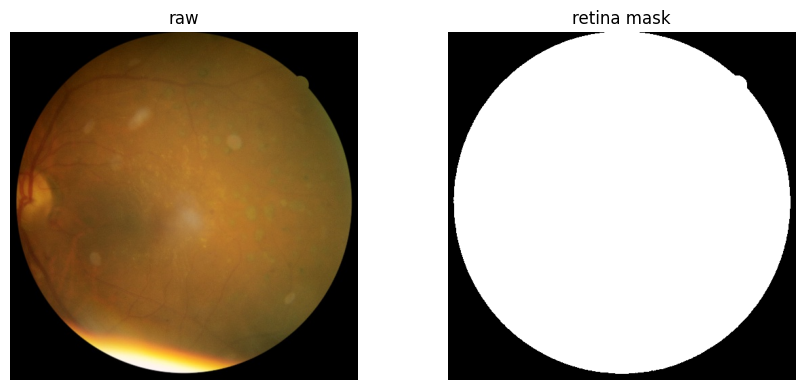

In [22]:
retina_region = retina_mask(demo_raw_image)
background_fraction = 1 - retina_region.mean()
print(f'background: {background_fraction:.1%} of pixels | retina: {1 - background_fraction:.1%}')

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
axes[0].imshow(cv2.cvtColor(demo_raw_image, cv2.COLOR_BGR2RGB)); axes[0].set_title('raw')
axes[1].imshow(retina_region, cmap='gray'); axes[1].set_title('retina mask')
for ax in axes:
    ax.axis('off')
save_figure('results/figures/fig4_retina_mask.png', dpi=150)

### 2.4 Crop, pad and resize

In [23]:
cropped_image = crop_to_retina(demo_raw_image)
square_image = pad_to_square(cropped_image)
resized_image = cv2.resize(square_image, (config.image_size, config.image_size), interpolation=cv2.INTER_AREA)

print(f'raw     : {demo_raw_image.shape[:2]}')
print(f'cropped : {cropped_image.shape[:2]}')
print(f'square  : {square_image.shape[:2]}')
print(f'resized : {resized_image.shape[:2]}')
print(f'pixels reduced by {1 - np.prod(resized_image.shape[:2]) / np.prod(demo_raw_image.shape[:2]):.1%}')

raw     : (512, 512)
cropped : (503, 496)
square  : (503, 503)
resized : (384, 384)
pixels reduced by 43.8%


### 2.5 Contrast enhancement (CLAHE on the green channel)
The histogram shows the green-channel intensities spreading out after CLAHE, which means higher contrast.

green channel contrast (std): 46.0 -> 48.5
figure saved: results/figures/fig6_clahe_effect.png


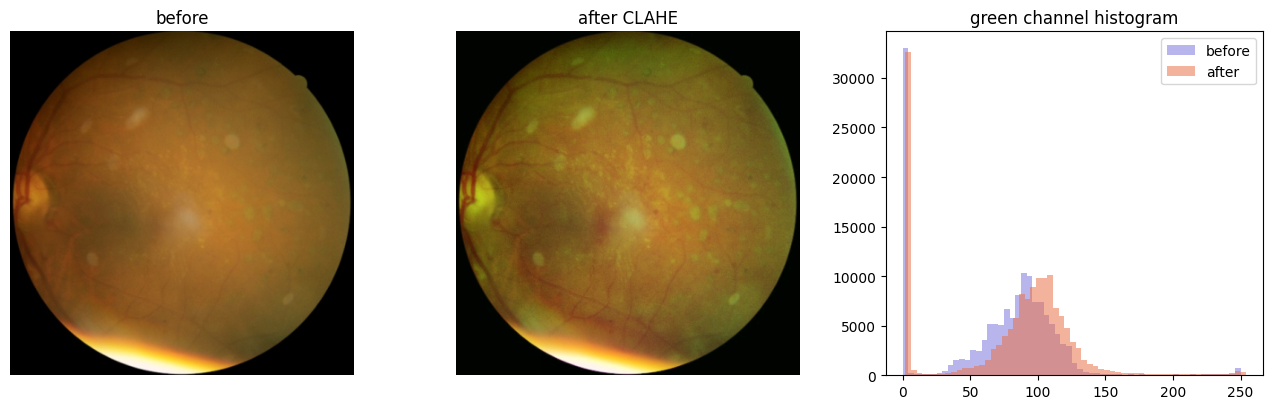

In [24]:
contrast_enhanced_image = clahe_green(resized_image)

green_std_before = resized_image[:, :, 1].std()
green_std_after = contrast_enhanced_image[:, :, 1].std()
print(f'green channel contrast (std): {green_std_before:.1f} -> {green_std_after:.1f}')

fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))
axes[0].imshow(cv2.cvtColor(resized_image, cv2.COLOR_BGR2RGB)); axes[0].set_title('before')
axes[1].imshow(cv2.cvtColor(contrast_enhanced_image, cv2.COLOR_BGR2RGB)); axes[1].set_title('after CLAHE')
axes[2].hist(resized_image[:, :, 1].ravel(), bins=60, alpha=0.55, label='before', color='#7F77DD')
axes[2].hist(contrast_enhanced_image[:, :, 1].ravel(), bins=60, alpha=0.55, label='after', color='#E8734A')
axes[2].set_title('green channel histogram'); axes[2].legend()
for ax in axes[:2]:
    ax.axis('off')
save_figure('results/figures/fig6_clahe_effect.png')

### 2.6 Illumination correction and edge enhancement
Measures uneven lighting as the brightness difference between the left and right thirds of the image, before and after correction.

In [25]:
def illumination_gradient(image):
    # brightness difference between left and right thirds
    third = image.shape[1] // 3
    return abs(float(image[:, :third].mean()) - float(image[:, -third:].mean()))


illumination_corrected_image = subtract_local_average(contrast_enhanced_image)
gradient_before = illumination_gradient(contrast_enhanced_image)
gradient_after = illumination_gradient(illumination_corrected_image)
print(f'illumination gradient: {gradient_before:.2f} -> {gradient_after:.2f} '
      f'({1 - gradient_after / max(gradient_before, 1e-6):.0%} reduction)')

illumination gradient: 6.94 -> 2.26 (67% reduction)


### 2.7 Illumination check on 40 images
Repeats the measurement on 40 random images to show the correction works across the dataset, not just on one image.

In [26]:
illumination_rows = []
for relative_path in ddr_images.sample(min(40, len(ddr_images)), random_state=RANDOM_SEED)['image']:
    image = cv2.imread(f'{DDR_FOLDER}/{relative_path}')
    if image is None:
        continue
    base = cv2.resize(pad_to_square(crop_to_retina(image)),
                      (config.image_size, config.image_size), interpolation=cv2.INTER_AREA)
    illumination_rows.append({'before': illumination_gradient(base),
                              'after': illumination_gradient(subtract_local_average(clahe_green(base)))})

illumination_results = pd.DataFrame(illumination_rows)
illumination_results['reduction_%'] = (1 - illumination_results['after']
                                       / illumination_results['before'].clip(lower=1e-6)) * 100
illumination_results.to_csv('results/tables/table3_illumination_reduction.csv', index=False)
show_table('Illumination gradient on 40 images', illumination_results.describe().round(2))
print(f"\nmean reduction: {illumination_results['reduction_%'].mean():.1f}%")


=== Illumination gradient on 40 images ===
       before  after  reduction_%
count   40.00  40.00        40.00
mean    14.18   0.86        87.67
std      8.87   0.68        27.12
min      0.09   0.02       -68.89
25%      7.59   0.42        90.26
50%     13.28   0.62        93.81
75%     17.90   1.07        96.72
max     32.95   3.15        99.60

mean reduction: 87.7%


### 2.8 All preprocessing stages

figure saved: results/figures/fig5_preprocessing_stages.png


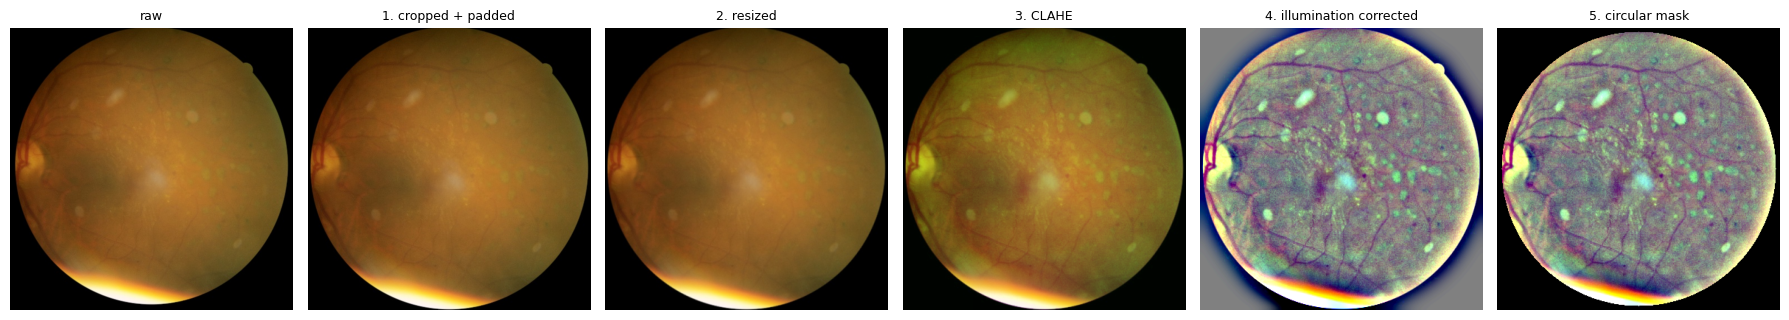

In [27]:
pipeline_stages = {
    'raw': demo_raw_image,
    '1. cropped + padded': square_image,
    '2. resized': resized_image,
    '3. CLAHE': contrast_enhanced_image,
    '4. illumination corrected': illumination_corrected_image,
    '5. circular mask': circular_crop(illumination_corrected_image),
}

fig, axes = plt.subplots(1, len(pipeline_stages), figsize=(3 * len(pipeline_stages), 3.4))
for ax, (stage_name, stage_image) in zip(axes, pipeline_stages.items()):
    ax.imshow(cv2.cvtColor(stage_image, cv2.COLOR_BGR2RGB))
    ax.set_title(stage_name, fontsize=9); ax.axis('off')
save_figure('results/figures/fig5_preprocessing_stages.png')

### 2.9 Preprocessing time per image

In [28]:
timing_paths = ddr_images.sample(min(20, len(ddr_images)), random_state=1)['image']
start_time = time.perf_counter()
for relative_path in timing_paths:
    image = cv2.imread(f'{DDR_FOLDER}/{relative_path}')
    if image is not None:
        preprocess_fundus(image, size=config.image_size)
ms_per_image = (time.perf_counter() - start_time) / len(timing_paths) * 1000
print(f'preprocessing time: {ms_per_image:.1f} ms per full-resolution image')

preprocessing time: 41.7 ms per full-resolution image


### 2.10 Preprocess every image once and cache it
Every image (DDR and APTOS) is preprocessed once and saved as a 384 x 384 JPEG. Training then reads the small cached files, which makes each epoch much faster and guarantees training, evaluation and Grad-CAM all see exactly the same preprocessing. Already-cached files are skipped on later runs.

In [29]:
CACHE_FOLDER = Path(config.cache_dir) / str(config.image_size)
CACHE_FOLDER.mkdir(parents=True, exist_ok=True)
DATASET_FOLDERS = {'DDR': DDR_FOLDER, 'APTOS': APTOS_FOLDER}


def cached_file_path(source, relative_path):
    flat_name = Path(relative_path).with_suffix('.jpg').as_posix().replace('/', '__')
    return str(CACHE_FOLDER / f'{source}__{flat_name}')


def cache_one_image(source_path, cached_path, size=config.image_size):
    if os.path.exists(cached_path):
        return True
    image = cv2.imread(source_path, cv2.IMREAD_COLOR)
    if image is None:
        return False
    # shrink very large images first to save time
    height, width = image.shape[:2]
    scale = 3 * size / max(height, width)
    if scale < 1:
        image = cv2.resize(image, (round(width * scale), round(height * scale)), interpolation=cv2.INTER_AREA)
    processed = preprocess_fundus(image, size, config.use_graham, config.use_clahe)
    return bool(cv2.imwrite(cached_path, processed, [cv2.IMWRITE_JPEG_QUALITY, 95]))


def build_cache(table):
    table = table.copy()
    table['cached'] = [cached_file_path(source, path) for source, path in zip(table['source'], table['image'])]
    jobs = [(f'{DATASET_FOLDERS[source]}/{path}', cached)
            for source, path, cached in zip(table['source'], table['image'], table['cached'])]
    with ThreadPoolExecutor(max_workers=os.cpu_count() or 4) as pool:
        succeeded = list(tqdm(pool.map(lambda job: cache_one_image(*job), jobs), total=len(jobs)))
    succeeded = np.array(succeeded, dtype=bool)
    if (~succeeded).sum():
        print(f'{int((~succeeded).sum())} unreadable images dropped')
    return table[succeeded].reset_index(drop=True)


start_time = time.time()
ddr_images = build_cache(ddr_images)
aptos_images = build_cache(aptos_images)
print(f'cache ready in {(time.time() - start_time) / 60:.1f} min')
print(f'cached images: {len(ddr_images)} DDR + {len(aptos_images)} APTOS -> {CACHE_FOLDER}')

  0%|          | 0/12522 [00:00<?, ?it/s]

Corrupt JPEG data: 35 extraneous bytes before marker 0xd9
Corrupt JPEG data: 38 extraneous bytes before marker 0xd9
Corrupt JPEG data: 34 extraneous bytes before marker 0xd9


  0%|          | 0/3662 [00:00<?, ?it/s]

cache ready in 10.9 min
cached images: 12522 DDR + 3662 APTOS -> /kaggle/working/cache/384


## 3. Data augmentation and class balancing

**Augmentation** creates a new random variation of each training image every time it is used, so the network does not memorise the rare classes. Only changes that keep the diagnosis the same are used:

| Augmentation | Setting | Reason |
|---|---|---|
| Horizontal / vertical flip | 50% each | left and right eyes are mirror images |
| Rotation | any angle, 70% | the camera has no fixed "up" |
| Zoom (scale) | 90-110% | framing varies between photos |
| Shift | up to 5% | the retina is not always centred |
| Brightness / contrast | +/-12%, 50% | flash and exposure vary between cameras |
| Light blur or noise | 20% | small focus and sensor differences |

Strong colour changes, large cut-outs and heavy blur are **not** used: colour carries diagnostic information, cut-outs can erase the few lesions that define a grade, and heavy blur is exactly what the quality head must learn to detect.

**Class balancing**: a weighted sampler draws rare grades (and ungradable images) more often, using effective-number weights that correct the imbalance without over-correcting.

### 3.1 Augmentation pipeline

In [30]:
IMAGENET_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
IMAGENET_STD = np.array([0.229, 0.224, 0.225], dtype=np.float32)


class FundusTransform:
    # train: flips, rotation / zoom / shift, brightness / contrast, light blur or noise
    # eval: resize + normalise only

    def __init__(self, size, train):
        self.size = size
        self.train = train

    def augment(self, image):
        rng = np.random
        if rng.rand() < 0.5:
            image = image[:, ::-1]                      # horizontal flip
        if rng.rand() < 0.5:
            image = image[::-1]                         # vertical flip
        image = np.ascontiguousarray(image)

        if rng.rand() < 0.7:                            # rotation + zoom + shift
            height, width = image.shape[:2]
            matrix = cv2.getRotationMatrix2D((width / 2, height / 2),
                                             rng.uniform(-180, 180), rng.uniform(0.9, 1.1))
            matrix[:, 2] += rng.uniform(-0.05, 0.05, size=2) * np.array([width, height])
            image = cv2.warpAffine(image, matrix, (width, height), flags=cv2.INTER_LINEAR,
                                   borderMode=cv2.BORDER_CONSTANT, borderValue=0)

        if rng.rand() < 0.5:                            # brightness / contrast
            contrast = 1 + rng.uniform(-0.12, 0.12)
            brightness = rng.uniform(-0.12, 0.12) * 255
            image = np.clip(image.astype(np.float32) * contrast + brightness, 0, 255).astype(np.uint8)

        if rng.rand() < 0.2:                            # light blur or noise
            if rng.rand() < 0.5:
                image = cv2.GaussianBlur(image, (3, 3), 0)
            else:
                noise = rng.normal(0, np.sqrt(rng.uniform(5, 20)), image.shape)
                image = np.clip(image.astype(np.float32) + noise, 0, 255).astype(np.uint8)
        return image

    def __call__(self, image_rgb):
        if image_rgb.shape[:2] != (self.size, self.size):
            image_rgb = cv2.resize(image_rgb, (self.size, self.size), interpolation=cv2.INTER_AREA)
        if self.train:
            image_rgb = self.augment(image_rgb)
        normalised = (image_rgb.astype(np.float32) / 255.0 - IMAGENET_MEAN) / IMAGENET_STD
        return torch.from_numpy(np.ascontiguousarray(normalised.transpose(2, 0, 1)))


def denormalise(image_tensor):
    # tensor -> RGB image in [0, 1] for plotting
    image = image_tensor.permute(1, 2, 0).cpu().numpy() * IMAGENET_STD + IMAGENET_MEAN
    return np.clip(image, 0, 1)


train_transform = FundusTransform(config.image_size, train=True)
eval_transform = FundusTransform(config.image_size, train=False)
print('training transform  : flips, rotation, zoom, shift, brightness/contrast, blur or noise, normalise')
print('evaluation transform: resize, normalise')

training transform  : flips, rotation, zoom, shift, brightness/contrast, blur or noise, normalise
evaluation transform: resize, normalise


### 3.2 Eight augmented views of one image
Each panel is a different random version of the same preprocessed image, as the network would see it during training.

figure saved: results/figures/fig7_augmentation_grid.png


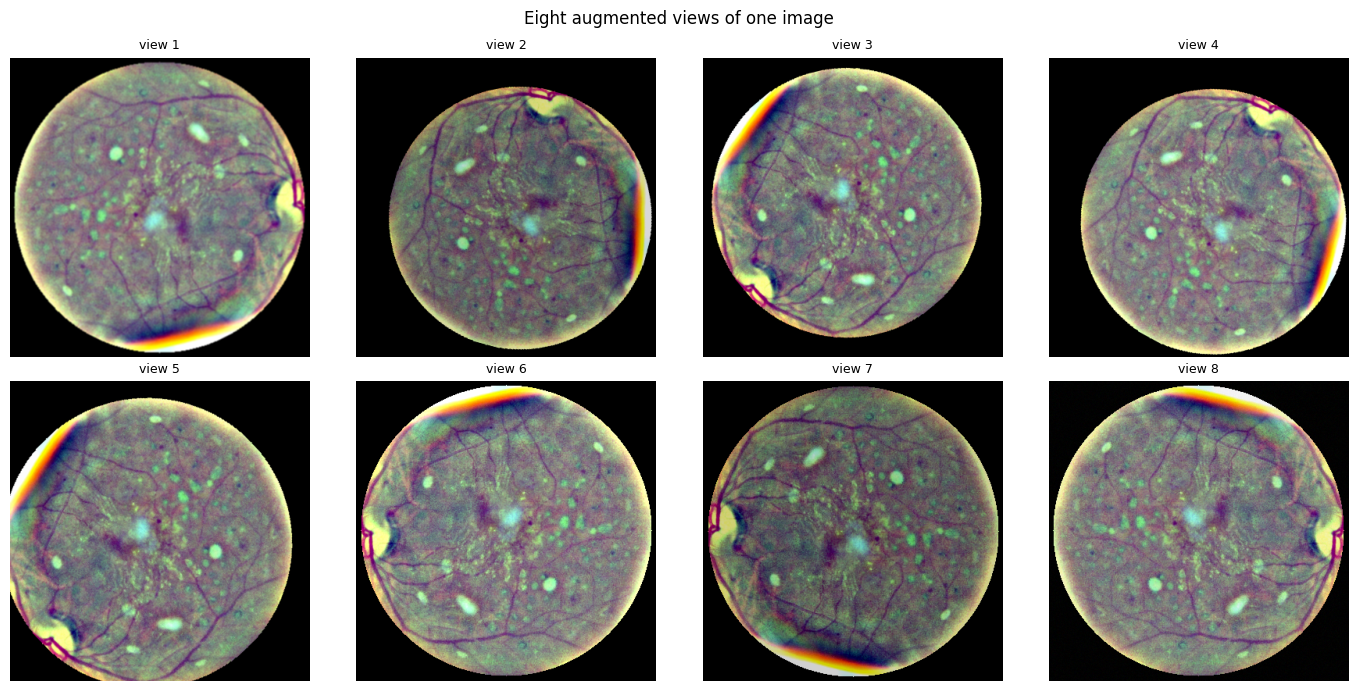

In [31]:
demo_preprocessed_rgb = cv2.cvtColor(preprocess_fundus(demo_raw_image, size=config.image_size), cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for view_number, ax in enumerate(axes.ravel(), start=1):
    ax.imshow(denormalise(train_transform(demo_preprocessed_rgb)))
    ax.axis('off'); ax.set_title(f'view {view_number}', fontsize=9)
plt.suptitle('Eight augmented views of one image')
save_figure('results/figures/fig7_augmentation_grid.png', dpi=150)

### 3.3 Class weights
Compares simple inverse-frequency weights with the effective-number weights used here. Ungradable images count as their own class.

In [32]:
def effective_number_weights(counts, beta=0.999):
    # class-balanced weights, mean weight = 1, zero for empty classes
    counts = np.asarray(counts, dtype=np.float64)
    effective_counts = (1.0 - np.power(beta, counts)) / (1.0 - beta)
    weights = np.where(counts > 0, 1.0 / np.maximum(effective_counts, 1e-8), 0.0)
    present = counts > 0
    weights = weights / weights[present].sum() * present.sum()
    return torch.tensor(weights, dtype=torch.float32)


train_set = ddr_images[ddr_images['split'] == 'train'].reset_index(drop=True)
validation_set = ddr_images[(ddr_images['split'] == 'val') & (~ddr_images['ungradable'])].reset_index(drop=True)

train_label_counts = train_set['raw_label'].value_counts().sort_index()
class_weights = effective_number_weights(train_label_counts.values, beta=config.sampler_beta)

class_weight_table = pd.DataFrame({
    'label': [LABEL_NAMES[label] for label in train_label_counts.index],
    'count': train_label_counts.values,
    'inverse_frequency_weight': (train_label_counts.max() / train_label_counts.values).round(2),
    'effective_number_weight': class_weights.numpy().round(3)})
show_table('Class weights (training split)', class_weight_table)


=== Class weights (training split) ===
              label  count  inverse_frequency_weight  effective_number_weight
0             No DR   4386                      1.00                    0.374
1         Mild NPDR    441                      9.95                    1.034
2     Moderate NPDR   3134                      1.40                    0.386
3       Severe NPDR    165                     26.58                    2.425
4  Proliferative DR    639                      6.86                    0.781


### 3.4 Check that the sampler rebalances the classes
Draws one epoch from the sampler and compares the class shares with the original data.

In [33]:
def build_balanced_sampler(labels, beta=0.999):
    labels = np.asarray(labels)
    weight_per_class = effective_number_weights(np.bincount(labels), beta).numpy()
    return WeightedRandomSampler(weights=torch.as_tensor(weight_per_class[labels], dtype=torch.double),
                                 num_samples=len(labels), replacement=True)


# ungradable images are their own sampling class (label 5)
balanced_sampler = build_balanced_sampler(train_set['raw_label'].values, beta=config.sampler_beta)
sampled_labels = train_set['raw_label'].values[list(balanced_sampler)]

sampler_effect = pd.DataFrame({
    'original_%': (train_set['raw_label'].value_counts(normalize=True).sort_index() * 100).round(1),
    'after_sampling_%': (pd.Series(sampled_labels).value_counts(normalize=True).sort_index() * 100).round(1),
})
sampler_effect.index = [LABEL_NAMES[label] for label in sampler_effect.index]
sampler_effect.to_csv('results/tables/table4_sampler_effect.csv')
show_table('Class share before and after balanced sampling', sampler_effect)


=== Class share before and after balanced sampling ===
                  original_%  after_sampling_%
No DR                   50.0              38.7
Mild NPDR                5.0              11.1
Moderate NPDR           35.8              28.9
Severe NPDR              1.9               9.7
Proliferative DR         7.3              11.7


### 3.5 Datasets and data loaders
The training loader uses the balanced sampler and augmentation; the validation loader uses plain images in a fixed order. Validation contains gradable images only, because it measures grading performance.

In [34]:
class FundusDataset(Dataset):
    # reads cached preprocessed images, returns (image, grade, quality)

    def __init__(self, table, image_size, train):
        self.table = table.reset_index(drop=True)
        self.transform = FundusTransform(image_size, train)

    def __len__(self):
        return len(self.table)

    def __getitem__(self, index):
        record = self.table.iloc[index]
        image = cv2.imread(record['cached'], cv2.IMREAD_COLOR)
        if image is None:
            raise FileNotFoundError(record['cached'])
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        return (self.transform(image),
                torch.tensor(int(record['level'])),
                torch.tensor(int(record['quality'])))


def seed_worker(worker_id):
    # different random augmentations in each loader worker
    worker_seed = torch.initial_seed() % 2 ** 32
    np.random.seed(worker_seed)
    random.seed(worker_seed)
    cv2.setNumThreads(0)


def make_loader(table, train, sampler=None, batch_size=None):
    return DataLoader(FundusDataset(table, config.image_size, train),
                      batch_size=batch_size or config.batch_size,
                      sampler=sampler, shuffle=False,
                      num_workers=config.num_workers,
                      pin_memory=config.device == 'cuda',
                      drop_last=train,
                      worker_init_fn=seed_worker)


train_loader = make_loader(train_set, train=True, sampler=balanced_sampler)
validation_loader = make_loader(validation_set, train=False, batch_size=config.batch_size * 2)

print(f'training images   : {len(train_set)} ({int(train_set.ungradable.sum())} ungradable)')
print(f'validation images : {len(validation_set)}')
print(f'batches per epoch : {len(train_loader)}')

training images   : 8765 (0 ungradable)
validation images : 1878
batches per epoch : 273


### 3.6 Check one batch
Confirms image shape, value range and labels before training.

In [35]:
batch_images, batch_grades, batch_quality = next(iter(train_loader))
print('images  :', tuple(batch_images.shape), batch_images.dtype,
      f'range [{batch_images.min():.2f}, {batch_images.max():.2f}]')
print('grades  :', tuple(batch_grades.shape), 'values', sorted(batch_grades.unique().tolist()))
print('quality :', tuple(batch_quality.shape), 'values', sorted(batch_quality.unique().tolist()))
show_table('Grades in this batch (-1 = ungradable)',
           pd.Series(batch_grades.numpy()).value_counts().sort_index().to_frame('images'))

images  : (32, 3, 384, 384) torch.float32 range [-2.12, 2.64]
grades  : (32,) values [0, 1, 2, 3, 4]
quality : (32,) values [0]

=== Grades in this batch (-1 = ungradable) ===
   images
0      14
1       2
2       9
3       5
4       2


## 4. CNN architecture and transfer learning

- **Backbone**: EfficientNetV2-S pretrained on ImageNet-21k (about 20M parameters). It gives high accuracy for its size and trains fast, which fits the Kaggle GPU time limit.
- **Transfer learning**: the pretrained layers are frozen for the first epoch while the new output layers learn, then the whole network is fine-tuned with a 10x smaller learning rate for the pretrained layers.
- **Two heads** on shared features:
  - **Grade head**: 4 outputs for ordinal (CORN) classification of the 5 DR stages
  - **Quality head**: 2 outputs, gradable / ungradable
- **Ordinal loss (CORN)**: DR stages are ordered, so predicting "No DR" for a proliferative eye must cost more than predicting "Severe". CORN splits the problem into four yes/no questions ("is the grade above 0?", "above 1?", ...).

### 4.1 Ordinal (CORN) loss functions

In [36]:
def corn_loss(logits, targets, num_classes=5):
    # 4 yes/no tasks "is grade > k"; task k only trained on images with grade > k-1
    total_loss = torch.zeros((), device=logits.device, dtype=torch.float32)
    term_count = 0
    for k in range(num_classes - 1):
        in_task = torch.ones_like(targets, dtype=torch.bool) if k == 0 else targets > (k - 1)
        if in_task.sum() == 0:
            continue
        task_targets = (targets[in_task] > k).float()
        total_loss = total_loss + F.binary_cross_entropy_with_logits(
            logits[in_task, k].float(), task_targets, reduction='sum')
        term_count += int(in_task.sum().item())
    return total_loss / max(term_count, 1)


def corn_cumulative_probs(logits):
    # probability that grade > k, for k = 0..3
    return torch.cumprod(torch.sigmoid(logits), dim=1)


def corn_predict(logits, threshold=0.5):
    # predicted grade = number of "yes" answers
    return (corn_cumulative_probs(logits) > threshold).sum(dim=1)


def corn_expected_grade(logits):
    # continuous severity score between 0 and 4
    return corn_cumulative_probs(logits).sum(dim=1)

### 4.2 Multi-task loss (grade + image quality)
Total loss = grade loss (gradable images only) + 0.3 x quality loss (class-weighted cross-entropy).

In [37]:
class MultiTaskLoss(nn.Module):

    def __init__(self, num_classes=5, quality_weight=0.3, quality_class_weights=None,
                 label_smoothing=0.05):
        super().__init__()
        self.num_classes = num_classes
        self.quality_weight = quality_weight
        self.label_smoothing = label_smoothing
        if quality_class_weights is None:
            quality_class_weights = torch.ones(2)
        self.register_buffer('quality_class_weights', quality_class_weights.float())

    def forward(self, grade_logits, quality_logits, grade_targets, quality_targets):
        # ungradable images (grade -1) are left out of the grade loss
        gradable = grade_targets >= 0
        if gradable.any():
            grade_loss = corn_loss(grade_logits[gradable], grade_targets[gradable], self.num_classes)
        else:
            grade_loss = torch.zeros((), device=grade_logits.device)

        has_quality_label = quality_targets >= 0
        if has_quality_label.any():
            quality_loss = F.cross_entropy(quality_logits[has_quality_label].float(),
                                           quality_targets[has_quality_label],
                                           weight=self.quality_class_weights,
                                           label_smoothing=self.label_smoothing)
        else:
            quality_loss = torch.zeros((), device=grade_logits.device)

        total_loss = grade_loss + self.quality_weight * quality_loss
        return total_loss, {'loss': float(total_loss.detach()),
                            'loss_grade': float(grade_loss.detach()),
                            'loss_quality': float(quality_loss.detach())}

### 4.3 Network definition

In [38]:
class DRTriageNet(nn.Module):

    def __init__(self, backbone_name, num_classes=5, num_quality_classes=2,
                 dropout=0.4, pretrained=True):
        super().__init__()
        self.num_classes = num_classes
        # pretrained CNN without its ImageNet classifier -> one feature vector per image
        self.backbone = timm.create_model(backbone_name, pretrained=pretrained, num_classes=0)
        feature_size = self.backbone.num_features
        self.dropout = nn.Dropout(p=dropout)
        self.grade_head = nn.Linear(feature_size, num_classes - 1)
        self.quality_head = nn.Linear(feature_size, num_quality_classes)
        for head in (self.grade_head, self.quality_head):
            nn.init.trunc_normal_(head.weight, std=0.01)
            nn.init.zeros_(head.bias)

    def forward_features(self, images):
        return self.backbone(images)

    def heads_from_features(self, features):
        dropped = self.dropout(features)
        return self.grade_head(dropped), self.quality_head(dropped)

    def forward(self, images):
        return self.heads_from_features(self.backbone(images))

    def freeze_backbone(self):
        for parameter in self.backbone.parameters():
            parameter.requires_grad = False

    def unfreeze_backbone(self):
        for parameter in self.backbone.parameters():
            parameter.requires_grad = True

    def param_groups(self, head_lr=1e-3, backbone_lr=1e-4):
        # smaller learning rate for the pretrained layers
        head_parameters = list(self.grade_head.parameters()) + list(self.quality_head.parameters())
        return [{'params': list(self.backbone.parameters()), 'lr': backbone_lr, 'name': 'backbone'},
                {'params': head_parameters, 'lr': head_lr, 'name': 'heads'}]


def build_model(settings, pretrained=None):
    return DRTriageNet(settings.backbone, num_classes=settings.num_classes,
                       num_quality_classes=settings.num_quality_classes,
                       dropout=settings.dropout,
                       pretrained=settings.pretrained if pretrained is None else pretrained)

### 4.4 Build the model with pretrained weights

In [39]:
model = build_model(config).to(config.device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print('backbone          :', config.backbone)
print(f'total parameters  : {total_params / 1e6:.1f}M')
print(f'trainable         : {trainable_params / 1e6:.1f}M')
print(f'feature size      : {model.backbone.num_features}')

model.safetensors:   0%|          | 0.00/86.5M [00:00<?, ?B/s]

backbone          : tf_efficientnetv2_s.in21k_ft_in1k
total parameters  : 20.2M
trainable         : 20.2M
feature size      : 1280


### 4.5 Output shape check

In [40]:
model.eval()
with torch.no_grad():
    grade_logits, quality_logits = model(batch_images[:4].to(config.device))
print('grade head output  :', tuple(grade_logits.shape), '-> 4 ordinal yes/no tasks')
print('quality head output:', tuple(quality_logits.shape), '-> gradable / ungradable')

grade head output  : (4, 4) -> 4 ordinal yes/no tasks
quality head output: (4, 2) -> gradable / ungradable


### 4.6 Parameters per part of the network

In [41]:
print(f'shared backbone : {sum(p.numel() for p in model.backbone.parameters()) / 1e6:.1f}M parameters')
print(f'grade head      : {sum(p.numel() for p in model.grade_head.parameters()):,} parameters')
print(f'quality head    : {sum(p.numel() for p in model.quality_head.parameters()):,} parameters')
print(f'quality loss weight: {config.quality_loss_weight}')

shared backbone : 20.2M parameters
grade head      : 5,124 parameters
quality head    : 2,562 parameters
quality loss weight: 0.3


### 4.7 The ordinal loss grows with distance from the true grade
Plain cross-entropy would give every wrong answer the same loss; CORN penalises bigger mistakes more.

In [42]:
true_grades = torch.tensor([4, 4, 4])

def corn_loss_for_prediction(predicted_grade):
    logits = torch.full((3, 4), -4.0)
    logits[:, :predicted_grade] = 4.0
    return float(corn_loss(logits, true_grades, config.num_classes))

for predicted_grade in [4, 3, 2, 1, 0]:
    print(f'true grade 4, predicted {predicted_grade}: CORN loss {corn_loss_for_prediction(predicted_grade):.3f}')

true grade 4, predicted 4: CORN loss 0.018
true grade 4, predicted 3: CORN loss 1.018
true grade 4, predicted 2: CORN loss 2.018
true grade 4, predicted 1: CORN loss 3.018
true grade 4, predicted 0: CORN loss 4.018


### 4.8 Probabilities are always in grade order
P(grade > k) never increases with k, so the predicted stages are always consistent.

In [43]:
with torch.no_grad():
    cumulative_probs = corn_cumulative_probs(grade_logits.float())
order_is_consistent = bool(((cumulative_probs[:, 1:] - cumulative_probs[:, :-1]) <= 1e-6).all())
print('P(grade > k) for 4 images (untrained heads):')
print(cumulative_probs.cpu().numpy().round(3))
print('probabilities non-increasing:', order_is_consistent)
print('expected grades:', corn_expected_grade(grade_logits.float()).cpu().numpy().round(2))

P(grade > k) for 4 images (untrained heads):
[[0.464 0.212 0.118 0.054]
 [0.415 0.194 0.108 0.049]
 [0.474 0.239 0.146 0.062]
 [0.487 0.231 0.127 0.057]]
probabilities non-increasing: True
expected grades: [0.85 0.77 0.92 0.9 ]


### 4.9 Learning rate per parameter group

In [44]:
for group in model.param_groups(config.head_lr, config.backbone_lr):
    print(f"{group['name']:10s} learning rate {group['lr']:.0e} | "
          f"{sum(p.numel() for p in group['params']) / 1e6:.1f}M parameters")

backbone   learning rate 1e-04 | 20.2M parameters
heads      learning rate 1e-03 | 0.0M parameters


## 5. Training

| Technique | Purpose |
|---|---|
| Frozen backbone in epoch 0 | protects pretrained features while the new heads start learning |
| Different learning rates (1e-4 backbone, 1e-3 heads) | gentle fine-tuning of pretrained layers |
| Warmup + cosine learning-rate schedule | stable start, smooth decay |
| Mixed precision (AMP) | about half the memory, faster training |
| Weight moving average (EMA) | smoother, more stable final weights |
| Gradient clipping | prevents unstable updates |
| Validation every epoch on QWK | measures ordinal grading quality |
| Early stopping (patience 4) | stops when validation QWK stops improving, limits overfitting |
| Checkpoints every epoch | training resumes automatically after a disconnect |

**Quadratic weighted kappa (QWK)** measures agreement between predicted and true grades, penalising large grade errors more than small ones. It is the model-selection metric.

### 5.1 Quadratic weighted kappa

In [45]:
from sklearn.metrics import cohen_kappa_score

def quadratic_weighted_kappa(true_grades, predicted_grades, num_classes=5):
    return float(cohen_kappa_score(true_grades, predicted_grades, weights='quadratic',
                                   labels=list(range(num_classes))))

### 5.2 Trainer
Runs the training and validation loops, records loss, accuracy and QWK per epoch, saves `last.pt` and `best.pt`, and applies early stopping.

In [46]:
def make_grad_scaler(enabled):
    if hasattr(torch.amp, 'GradScaler'):
        return torch.amp.GradScaler('cuda', enabled=enabled)
    return torch.cuda.amp.GradScaler(enabled=enabled)


class WeightAverage:
    # exponential moving average (EMA) of the model weights

    def __init__(self, model, decay=0.999):
        self.decay = decay
        self.shadow = copy.deepcopy(model).eval()
        for parameter in self.shadow.parameters():
            parameter.requires_grad_(False)

    @torch.no_grad()
    def update(self, model):
        for average, current in zip(self.shadow.parameters(), model.parameters()):
            average.mul_(self.decay).add_(current.detach(), alpha=1.0 - self.decay)
        for average_buffer, current_buffer in zip(self.shadow.buffers(), model.buffers()):
            average_buffer.copy_(current_buffer)


def warmup_cosine_schedule(warmup_steps, total_steps):
    def learning_rate_factor(step):
        if step < warmup_steps:
            return (step + 1) / max(warmup_steps, 1)
        progress = (step - warmup_steps) / max(total_steps - warmup_steps, 1)
        return 0.5 * (1.0 + np.cos(np.pi * min(progress, 1.0)))
    return learning_rate_factor


class Trainer:

    def __init__(self, model, settings, train_loader, validation_loader, quality_class_weights=None):
        self.model = model.to(settings.device)
        self.settings = settings
        self.train_loader = train_loader
        self.validation_loader = validation_loader
        self.device = settings.device
        self.device_type = 'cuda' if settings.device.startswith('cuda') else 'cpu'

        self.loss_fn = MultiTaskLoss(settings.num_classes, settings.quality_loss_weight,
                                     quality_class_weights, settings.label_smoothing).to(settings.device)
        self.optimizer = torch.optim.AdamW(model.param_groups(settings.head_lr, settings.backbone_lr),
                                           weight_decay=settings.weight_decay)
        total_steps = settings.epochs * max(len(train_loader), 1)
        self.scheduler = torch.optim.lr_scheduler.LambdaLR(
            self.optimizer, warmup_cosine_schedule(settings.warmup_steps, total_steps))
        self.grad_scaler = make_grad_scaler(settings.amp)
        self.weight_average = WeightAverage(model, settings.ema_decay) if settings.use_ema else None

        self.start_epoch = 0
        self.best_qwk = -1.0
        self.epochs_without_improvement = 0
        self.history = []

        self.checkpoint_folder = Path(settings.checkpoint_dir)
        self.checkpoint_folder.mkdir(parents=True, exist_ok=True)
        self.last_checkpoint = self.checkpoint_folder / 'last.pt'
        self.best_checkpoint = self.checkpoint_folder / 'best.pt'

    def save_checkpoint(self, epoch, is_best=False):
        state = {
            'epoch': epoch,
            'model': self.model.state_dict(),
            'optimizer': self.optimizer.state_dict(),
            'scheduler': self.scheduler.state_dict(),
            'grad_scaler': self.grad_scaler.state_dict(),
            'ema': self.weight_average.shadow.state_dict() if self.weight_average else None,
            'best_qwk': self.best_qwk,
            'epochs_without_improvement': self.epochs_without_improvement,
            'history': self.history,
            'torch_rng': torch.get_rng_state(),
            'numpy_rng': np.random.get_state(),
            'config': self.settings.to_dict(),
        }
        # write to a temp file then rename, so a crash cannot corrupt last.pt
        temp_file = self.last_checkpoint.with_suffix('.tmp')
        torch.save(state, temp_file)
        os.replace(temp_file, self.last_checkpoint)
        if is_best:
            torch.save(state, self.best_checkpoint)
        (self.checkpoint_folder / 'history.json').write_text(json.dumps(self.history, indent=2))

    def resume_if_possible(self):
        if not self.last_checkpoint.exists():
            print('[resume] no checkpoint found - starting from scratch')
            return False
        state = torch.load(self.last_checkpoint, map_location=self.device, weights_only=False)
        self.model.load_state_dict(state['model'])
        self.optimizer.load_state_dict(state['optimizer'])
        self.scheduler.load_state_dict(state['scheduler'])
        self.grad_scaler.load_state_dict(state['grad_scaler'])
        if self.weight_average and state.get('ema'):
            self.weight_average.shadow.load_state_dict(state['ema'])
        self.best_qwk = state['best_qwk']
        self.epochs_without_improvement = state['epochs_without_improvement']
        self.history = state['history']
        self.start_epoch = state['epoch'] + 1
        torch.set_rng_state(state['torch_rng'].cpu())
        np.random.set_state(state['numpy_rng'])
        print(f"[resume] restored from epoch {state['epoch']}, best QWK so far {self.best_qwk:.4f} "
              f"- continuing at epoch {self.start_epoch}")
        return True

    def train_one_epoch(self):
        self.model.train()
        loss_sums, batch_count = {}, 0
        correct, graded_total = 0, 0
        start_time = time.time()
        for images, grade_targets, quality_targets in tqdm(self.train_loader, leave=False):
            images = images.to(self.device, non_blocking=True)
            grade_targets = grade_targets.to(self.device, non_blocking=True)
            quality_targets = quality_targets.to(self.device, non_blocking=True)

            self.optimizer.zero_grad(set_to_none=True)
            with torch.autocast(device_type=self.device_type, enabled=self.settings.amp):
                grade_logits, quality_logits = self.model(images)
            grade_logits, quality_logits = grade_logits.float(), quality_logits.float()
            loss, loss_parts = self.loss_fn(grade_logits, quality_logits, grade_targets, quality_targets)

            self.grad_scaler.scale(loss).backward()
            self.grad_scaler.unscale_(self.optimizer)
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), self.settings.grad_clip)
            self.grad_scaler.step(self.optimizer)
            self.grad_scaler.update()
            self.scheduler.step()
            if self.weight_average:
                self.weight_average.update(self.model)

            # training accuracy on gradable images
            gradable = grade_targets >= 0
            with torch.no_grad():
                predicted = corn_predict(grade_logits.detach())
            correct += int((predicted[gradable] == grade_targets[gradable]).sum())
            graded_total += int(gradable.sum())

            for name, value in loss_parts.items():
                loss_sums[name] = loss_sums.get(name, 0.0) + value
            batch_count += 1

        result = {f'train_{name}': total / max(batch_count, 1) for name, total in loss_sums.items()}
        result['train_accuracy'] = correct / max(graded_total, 1)
        result['epoch_seconds'] = time.time() - start_time
        result['lr'] = self.optimizer.param_groups[0]['lr']
        return result

    @torch.no_grad()
    def validate(self, use_average=True):
        model = self.weight_average.shadow if (self.weight_average and use_average) else self.model
        model.eval()
        predictions, targets, losses = [], [], []
        for images, grade_targets, quality_targets in self.validation_loader:
            images = images.to(self.device, non_blocking=True)
            grade_targets = grade_targets.to(self.device, non_blocking=True)
            quality_targets = quality_targets.to(self.device, non_blocking=True)
            with torch.autocast(device_type=self.device_type, enabled=self.settings.amp):
                grade_logits, quality_logits = model(images)
            grade_logits, quality_logits = grade_logits.float(), quality_logits.float()
            loss, _ = self.loss_fn(grade_logits, quality_logits, grade_targets, quality_targets)
            losses.append(float(loss))
            predictions.append(corn_predict(grade_logits).cpu().numpy())
            targets.append(grade_targets.cpu().numpy())

        predicted_grades, true_grades = np.concatenate(predictions), np.concatenate(targets)
        return {'val_loss': float(np.mean(losses)),
                'val_accuracy': float((predicted_grades == true_grades).mean()),
                'val_qwk': quadratic_weighted_kappa(true_grades, predicted_grades)}

    def fit(self):
        # safe to re-run: continues from last.pt
        self.resume_if_possible()
        if self.epochs_without_improvement >= self.settings.patience:
            print('[resume] training already finished (early stopped)')
            return self.history

        for epoch in range(self.start_epoch, self.settings.epochs):
            if epoch == 0 and self.settings.freeze_first_epoch:
                self.model.freeze_backbone()
                print('[stage 1] backbone frozen - training the new heads only')
            elif epoch == 1 or (epoch == 0 and not self.settings.freeze_first_epoch):
                self.model.unfreeze_backbone()
                print('[stage 2] backbone unfrozen - fine-tuning the whole network')

            record = {'epoch': epoch, **self.train_one_epoch(), **self.validate()}
            self.history.append(record)
            print(f"epoch {epoch:02d} | train loss {record['train_loss']:.4f} | "
                  f"train acc {record['train_accuracy']:.3f} | val loss {record['val_loss']:.4f} | "
                  f"val acc {record['val_accuracy']:.3f} | val QWK {record['val_qwk']:.4f} | "
                  f"{record['epoch_seconds']:.0f}s")

            improved = record['val_qwk'] > self.best_qwk + self.settings.min_delta
            if improved:
                self.best_qwk = record['val_qwk']
                self.epochs_without_improvement = 0
                print(f'           new best validation QWK: {self.best_qwk:.4f} (saved best.pt)')
            else:
                self.epochs_without_improvement += 1
            self.save_checkpoint(epoch, is_best=improved)

            if self.epochs_without_improvement >= self.settings.patience:
                print(f'[early stop] no QWK improvement for {self.settings.patience} epochs')
                break
        return self.history

### 5.3 Create the trainer
The quality loss is class-weighted because ungradable images are much rarer than gradable ones.

In [47]:
quality_counts = np.bincount(train_set['quality'].values, minlength=2)
trainer = Trainer(model, config, train_loader, validation_loader,
                  quality_class_weights=effective_number_weights(quality_counts))
print(f'quality labels in training: {quality_counts[0]} gradable, {quality_counts[1]} ungradable')
print(f'checkpoints saved to      : {config.checkpoint_dir}')

quality labels in training: 8765 gradable, 0 ungradable
checkpoints saved to      : /kaggle/working/checkpoints


### 5.4 One-batch overfit test
A quick check before the long run: a fresh model trained on only 8 images should drive its loss close to zero. If it cannot, something in the data, model or loss is broken.

In [48]:
probe_model = build_model(config).to(config.device)
probe_model.train()
probe_loss_fn = MultiTaskLoss(config.num_classes, config.quality_loss_weight).to(config.device)
probe_optimizer = torch.optim.AdamW(probe_model.parameters(), lr=3e-4)

probe_images = batch_images[:8].to(config.device)
probe_grades = batch_grades[:8].to(config.device)
probe_quality = batch_quality[:8].to(config.device)

for step in range(30):
    probe_optimizer.zero_grad()
    loss, loss_parts = probe_loss_fn(*probe_model(probe_images), probe_grades, probe_quality)
    loss.backward()
    probe_optimizer.step()
    if step % 10 == 0 or step == 29:
        print(f"step {step:2d} | total loss {loss_parts['loss']:.4f} | grade loss {loss_parts['loss_grade']:.4f}")

del probe_model, probe_optimizer
if config.device == 'cuda':
    torch.cuda.empty_cache()

step  0 | total loss 0.9085 | grade loss 0.7497
step 10 | total loss 0.0824 | grade loss 0.0455
step 20 | total loss 0.0491 | grade loss 0.0098
step 29 | total loss 0.0435 | grade loss 0.0054


### 5.5 Train the model
Prints training and validation loss, accuracy and QWK for every epoch. If the session disconnects, running this cell again continues from the last saved epoch.

In [49]:
seed_everything()
training_history = trainer.fit()
print(f'\nbest validation QWK: {trainer.best_qwk:.4f}')

[resume] no checkpoint found - starting from scratch
[stage 1] backbone frozen - training the new heads only


  0%|          | 0/273 [00:00<?, ?it/s]

epoch 00 | train loss 0.5574 | train acc 0.406 | val loss 0.6600 | val acc 0.445 | val QWK 0.1901 | 59s
           new best validation QWK: 0.1901 (saved best.pt)
[stage 2] backbone unfrozen - fine-tuning the whole network


  0%|          | 0/273 [00:00<?, ?it/s]

epoch 01 | train loss 0.3401 | train acc 0.666 | val loss 0.5553 | val acc 0.456 | val QWK 0.3674 | 171s
           new best validation QWK: 0.3674 (saved best.pt)


...

epoch 17 | train loss 0.0148 | train acc 0.989 | val loss 0.3011 | val acc 0.855 | val QWK 0.8906 | 145s


  0%|          | 0/273 [00:00<?, ?it/s]

epoch 18 | train loss 0.0125 | train acc 0.991 | val loss 0.3119 | val acc 0.862 | val QWK 0.8923 | 146s


  0%|          | 0/273 [00:00<?, ?it/s]

epoch 19 | train loss 0.0123 | train acc 0.990 | val loss 0.3332 | val acc 0.864 | val QWK 0.8947 | 145s
[early stop] no QWK improvement for 4 epochs

best validation QWK: 0.8960


### 5.6 Accuracy and loss curves
Training vs validation **loss** and **accuracy**, validation QWK, and the learning-rate schedule. Training accuracy is measured on augmented, class-balanced batches, so it is not directly comparable with validation accuracy early in training; the trend over epochs is what matters.


=== Training history ===
    epoch  train_loss  val_loss  train_accuracy  val_accuracy  val_qwk      lr
0       0      0.5574    0.6600          0.4065        0.4446   0.1901  0.0001
1       1      0.3401    0.5553          0.6659        0.4563   0.3674  0.0001
2       2      0.2517    0.4887          0.7690        0.4995   0.5122  0.0001
3       3      0.1922    0.4350          0.8318        0.5719   0.6163  0.0001
4       4      0.1568    0.3495          0.8602        0.6949   0.7444  0.0001
5       5      0.1339    0.2804          0.8837        0.7764   0.8283  0.0001
6       6      0.1146    0.2591          0.9026        0.7929   0.8498  0.0001
7       7      0.0929    0.2232          0.9236        0.8216   0.8639  0.0001
8       8      0.0747    0.2017          0.9344        0.8365   0.8730  0.0001
9       9      0.0703    0.1949          0.9408        0.8424   0.8762  0.0001
10     10      0.0585    0.1983          0.9508        0.8536   0.8866  0.0001
11     11      0.0473    0

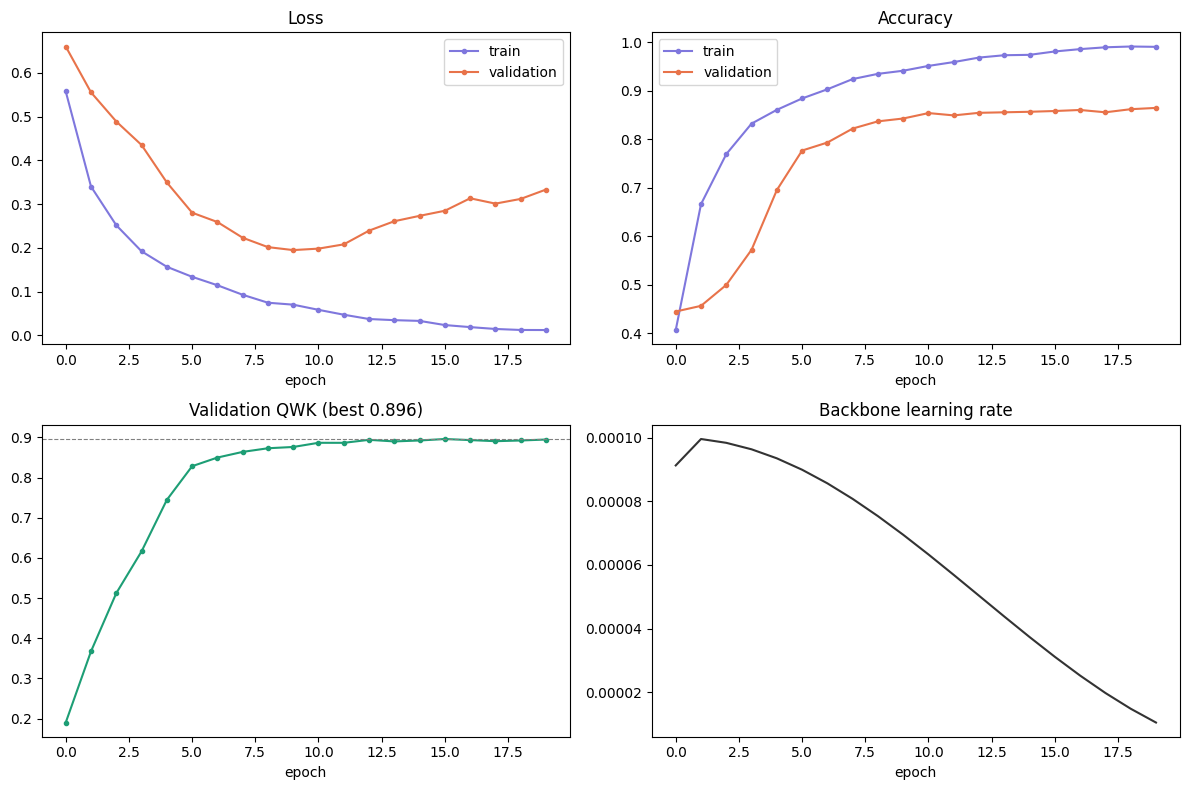

In [50]:
history_table = pd.DataFrame(training_history)
history_table.to_csv('results/logs/history.csv', index=False)
show_table('Training history',
           history_table[['epoch', 'train_loss', 'val_loss', 'train_accuracy', 'val_accuracy', 'val_qwk', 'lr']].round(4))

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes[0, 0].plot(history_table.epoch, history_table.train_loss, 'o-', ms=3, label='train', color='#7F77DD')
axes[0, 0].plot(history_table.epoch, history_table.val_loss, 'o-', ms=3, label='validation', color='#E8734A')
axes[0, 0].set_title('Loss'); axes[0, 0].legend()

axes[0, 1].plot(history_table.epoch, history_table.train_accuracy, 'o-', ms=3, label='train', color='#7F77DD')
axes[0, 1].plot(history_table.epoch, history_table.val_accuracy, 'o-', ms=3, label='validation', color='#E8734A')
axes[0, 1].set_title('Accuracy'); axes[0, 1].legend()

axes[1, 0].plot(history_table.epoch, history_table.val_qwk, 'o-', ms=3, color='#1D9E75')
axes[1, 0].axhline(history_table.val_qwk.max(), ls='--', lw=0.8, color='grey')
axes[1, 0].set_title(f'Validation QWK (best {history_table.val_qwk.max():.3f})')

axes[1, 1].plot(history_table.epoch, history_table.lr, color='#333')
axes[1, 1].set_title('Backbone learning rate')
for ax in axes.ravel():
    ax.set_xlabel('epoch')
save_figure('results/figures/fig9_training_curves.png')

### 5.7 Overfitting check
A growing gap between training and validation loss, while validation QWK stops improving, would indicate overfitting.

In [51]:
loss_gap = history_table.val_loss - history_table.train_loss
best_epoch = int(history_table.loc[history_table.val_qwk.idxmax(), 'epoch'])
print(f'validation - training loss gap: first epoch {loss_gap.iloc[0]:.3f} -> last epoch {loss_gap.iloc[-1]:.3f}')
print(f'best epoch (highest validation QWK): {best_epoch}')
if len(history_table) >= 3:
    print(f'QWK still improving in final 3 epochs: {bool(history_table.val_qwk.iloc[-1] >= history_table.val_qwk.iloc[-3])}')
stopped_early = len(history_table) < config.epochs
print(f'epochs run: {len(history_table)} / {config.epochs} ({"early stopped" if stopped_early else "completed"})')

validation - training loss gap: first epoch 0.103 -> last epoch 0.321
best epoch (highest validation QWK): 15
QWK still improving in final 3 epochs: True
epochs run: 20 / 25 (early stopped)


## 6. Evaluation

The best checkpoint is tested on the held-out DDR test split and on the external APTOS set.

- **Stage classification (5 classes)**: accuracy, precision, recall and F1-score per stage, macro and weighted averages, confusion matrix, QWK
- **DR detection** (any DR vs No DR) and **referable DR** (grade 2 or higher vs lower): accuracy, precision, recall (sensitivity), specificity, F1, ROC AUC
- **Uncertainty**: each image is predicted 20 times with dropout switched on (MC dropout); the spread of these predictions is the model's uncertainty. Calibration and risk-coverage show whether that uncertainty is useful.
- **Triage policy**: ungradable -> re-capture; uncertain -> human grader; grade 2 or higher -> refer; otherwise routine rescreen.

### 6.1 Metric functions

In [52]:
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix, f1_score,
                             precision_score, recall_score, roc_auc_score, roc_curve)

_trapezoid = getattr(np, 'trapezoid', None) or np.trapz


def per_class_report(true_grades, predicted_grades, num_classes=5):
    labels = list(range(num_classes))
    return {
        'accuracy': float(accuracy_score(true_grades, predicted_grades)),
        'qwk': quadratic_weighted_kappa(true_grades, predicted_grades, num_classes),
        'macro_precision': float(precision_score(true_grades, predicted_grades, average='macro', labels=labels, zero_division=0)),
        'macro_recall': float(recall_score(true_grades, predicted_grades, average='macro', labels=labels, zero_division=0)),
        'macro_f1': float(f1_score(true_grades, predicted_grades, average='macro', labels=labels, zero_division=0)),
        'weighted_f1': float(f1_score(true_grades, predicted_grades, average='weighted', labels=labels, zero_division=0)),
        'precision_per_class': precision_score(true_grades, predicted_grades, average=None, labels=labels, zero_division=0).tolist(),
        'recall_per_class': recall_score(true_grades, predicted_grades, average=None, labels=labels, zero_division=0).tolist(),
        'f1_per_class': f1_score(true_grades, predicted_grades, average=None, labels=labels, zero_division=0).tolist(),
        'confusion_matrix': confusion_matrix(true_grades, predicted_grades, labels=labels).tolist(),
    }


def binary_report(true_positive, predicted_positive):
    # accuracy, precision, recall (sensitivity), specificity, F1 for a yes/no decision
    true_positive = np.asarray(true_positive).astype(int)
    predicted_positive = np.asarray(predicted_positive).astype(int)
    tn, fp, fn, tp = confusion_matrix(true_positive, predicted_positive, labels=[0, 1]).ravel()
    return {'accuracy': float((tp + tn) / max(tp + tn + fp + fn, 1)),
            'precision': float(tp / max(tp + fp, 1)),
            'recall_sensitivity': float(tp / max(tp + fn, 1)),
            'specificity': float(tn / max(tn + fp, 1)),
            'f1': float(2 * tp / max(2 * tp + fp + fn, 1)),
            'tp': int(tp), 'fp': int(fp), 'fn': int(fn), 'tn': int(tn)}


def sensitivity_at_specificity(true_positive, scores, target_specificity=0.95):
    false_positive_rate, true_positive_rate, thresholds = roc_curve(true_positive, scores)
    specificity = 1.0 - false_positive_rate
    feasible = np.where(specificity >= target_specificity)[0]
    if feasible.size == 0:
        return {'specificity': float(specificity.max()), 'sensitivity': 0.0, 'threshold': float(thresholds[0])}
    best = feasible[np.argmax(true_positive_rate[feasible])]
    return {'specificity': float(specificity[best]), 'sensitivity': float(true_positive_rate[best]),
            'threshold': float(thresholds[best])}


def referable_dr_metrics(true_grades, expected_grades, threshold=2):
    # referable DR = grade 2 or higher
    is_referable = (np.asarray(true_grades) >= threshold).astype(int)
    scores = np.asarray(expected_grades, dtype=float)
    result = {'auc': float(roc_auc_score(is_referable, scores)), 'prevalence': float(is_referable.mean())}
    for specificity in (0.90, 0.95):
        result[f'sens_at_spec_{int(specificity * 100)}'] = sensitivity_at_specificity(is_referable, scores, specificity)
    return result


def expected_calibration_error(confidences, is_correct, n_bins=15):
    confidences = np.asarray(confidences, dtype=float)
    is_correct = np.asarray(is_correct, dtype=float)
    edges = np.linspace(0.0, 1.0, n_bins + 1)
    ece, mce, bins = 0.0, 0.0, []
    for low, high in zip(edges[:-1], edges[1:]):
        in_bin = (confidences > low) & (confidences <= high)
        if not in_bin.any():
            continue
        bin_accuracy, bin_confidence = is_correct[in_bin].mean(), confidences[in_bin].mean()
        gap = abs(bin_accuracy - bin_confidence)
        ece += in_bin.mean() * gap
        mce = max(mce, gap)
        bins.append({'low': float(low), 'high': float(high), 'images': int(in_bin.sum()),
                     'accuracy': float(bin_accuracy), 'confidence': float(bin_confidence)})
    return {'ece': float(ece), 'mce': float(mce), 'bins': bins}


def risk_coverage_curve(true_grades, predicted_grades, uncertainty, n_points=21):
    # keep the most certain images, defer the rest to a human
    true_grades, predicted_grades = np.asarray(true_grades), np.asarray(predicted_grades)
    most_certain_first = np.argsort(np.asarray(uncertainty, dtype=float))
    total = len(true_grades)
    points = []
    for coverage in np.linspace(1.0, 0.1, n_points):
        kept_count = max(int(round(coverage * total)), 2)
        kept = most_certain_first[:kept_count]
        accuracy = float(accuracy_score(true_grades[kept], predicted_grades[kept]))
        points.append({'coverage': float(kept_count / total), 'accuracy': accuracy, 'risk': 1.0 - accuracy,
                       'qwk': quadratic_weighted_kappa(true_grades[kept], predicted_grades[kept]),
                       'images_kept': kept_count})
    coverages = np.array([p['coverage'] for p in points])
    risks = np.array([p['risk'] for p in points])
    return {'points': points, 'aurc': float(_trapezoid(risks[::-1], coverages[::-1]))}


def full_evaluation(true_grades, predicted_grades, expected_grades, uncertainty=None, confidences=None):
    results = per_class_report(true_grades, predicted_grades)
    results['dr_detection'] = binary_report(np.asarray(true_grades) >= 1, np.asarray(predicted_grades) >= 1)
    results['referable_decision'] = binary_report(np.asarray(true_grades) >= 2, np.asarray(predicted_grades) >= 2)
    results['referable'] = referable_dr_metrics(true_grades, expected_grades)
    if confidences is not None:
        is_correct = (np.asarray(true_grades) == np.asarray(predicted_grades)).astype(float)
        results['calibration'] = expected_calibration_error(confidences, is_correct)
    if uncertainty is not None:
        results['selective'] = risk_coverage_curve(true_grades, predicted_grades, uncertainty)
    return results

### 6.2 MC dropout uncertainty and triage policy
The expensive backbone runs once per image; only the dropout and the small heads are repeated 20 times, so uncertainty costs almost nothing extra.

In [53]:
def enable_mc_dropout(model):
    # evaluation mode, but dropout stays active
    model.eval()
    for module in model.modules():
        if isinstance(module, nn.Dropout):
            module.train()


def cumulative_to_grade_probs(cumulative):
    # P(grade > k) -> probability of each grade 0-4
    ones = torch.ones_like(cumulative[:, :1])
    padded = torch.cat([ones, cumulative, torch.zeros_like(cumulative[:, :1])], dim=1)
    return padded[:, :-1] - padded[:, 1:]


@torch.no_grad()
def mc_dropout_predict(model, images, n_samples=20):
    enable_mc_dropout(model)
    features = model.forward_features(images).float()
    cumulative_samples, severity_samples, quality_samples = [], [], []
    for _ in range(n_samples):
        grade_logits, quality_logits = model.heads_from_features(features)
        cumulative_samples.append(corn_cumulative_probs(grade_logits))
        severity_samples.append(corn_expected_grade(grade_logits))
        quality_samples.append(F.softmax(quality_logits, dim=1))
    mean_cumulative = torch.stack(cumulative_samples).mean(dim=0)
    severity = torch.stack(severity_samples)
    grade_probs = cumulative_to_grade_probs(mean_cumulative).clamp(min=0)
    return {
        'grade': (mean_cumulative > 0.5).sum(dim=1).cpu().numpy(),
        'expected_grade': severity.mean(dim=0).cpu().numpy(),
        'uncertainty': severity.std(dim=0).cpu().numpy(),
        'confidence': grade_probs.max(dim=1).values.cpu().numpy(),
        'entropy': (-(grade_probs * torch.log(grade_probs + 1e-12)).sum(dim=1)).cpu().numpy(),
        'quality_probs': torch.stack(quality_samples).mean(dim=0).cpu().numpy(),
    }


def make_triage_decision(predictions, index, settings):
    # 1 ungradable -> re-capture | 2 uncertain -> human | 3 grade >= 2 -> refer | 4 routine
    p_ungradable = float(predictions['quality_probs'][index][1])
    grade = int(predictions['grade'][index])
    confidence = float(predictions['confidence'][index])
    uncertainty = float(predictions['uncertainty'][index])
    borderline_quality = p_ungradable > 0.6 * settings.ungradable_threshold

    if p_ungradable > settings.ungradable_threshold:
        action = 'Re-capture image'
    elif (uncertainty > settings.uncertainty_threshold or confidence < settings.confidence_threshold
          or (borderline_quality and confidence < settings.confidence_threshold + 0.10)):
        action = 'Refer for human grading'
    elif grade >= 2:
        action = 'Refer to ophthalmology'
    else:
        action = 'Routine rescreen'
    return {'grade': grade, 'grade_name': GRADE_NAMES[grade], 'confidence': confidence,
            'uncertainty': uncertainty, 'p_ungradable': p_ungradable, 'action': action}


def sweep_referral_thresholds(uncertainty, true_grades, predicted_grades,
                              deferral_rates=(0.0, 0.05, 0.10, 0.20, 0.30)):
    uncertainty = np.asarray(uncertainty, dtype=float)
    true_grades, predicted_grades = np.asarray(true_grades), np.asarray(predicted_grades)
    rows = []
    for deferral_rate in deferral_rates:
        kept_count = max(int(round((1.0 - deferral_rate) * len(true_grades))), 1)
        cutoff = np.sort(uncertainty)[kept_count - 1]
        kept = uncertainty <= cutoff
        truly_referable, predicted_referable = true_grades[kept] >= 2, predicted_grades[kept] >= 2
        rows.append({'deferred_%': int(deferral_rate * 100),
                     'uncertainty_cutoff': float(cutoff),
                     'images_kept': int(kept.sum()),
                     'accuracy_on_kept': float((true_grades[kept] == predicted_grades[kept]).mean()),
                     'referable_sensitivity_on_kept': float((predicted_referable & truly_referable).sum()
                                                            / max(truly_referable.sum(), 1))})
    return rows

### 6.3 Load the best checkpoint
The weight-averaged (EMA) weights from the epoch with the highest validation QWK.

In [54]:
best_checkpoint = torch.load(Path(config.checkpoint_dir) / 'best.pt', map_location=config.device, weights_only=False)
best_weights = best_checkpoint['ema'] if (config.use_ema and best_checkpoint.get('ema')) else best_checkpoint['model']

evaluation_model = build_model(config, pretrained=False).to(config.device)
evaluation_model.load_state_dict(best_weights)
evaluation_model.eval()
print(f"loaded best checkpoint: epoch {best_checkpoint['epoch']} | validation QWK {best_checkpoint['best_qwk']:.4f}")

loaded best checkpoint: epoch 15 | validation QWK 0.8960


### 6.4 Prediction helper

In [55]:
def predict_images(table, name):
    loader = make_loader(table, train=False)
    keys = ['grade', 'expected_grade', 'uncertainty', 'confidence', 'entropy', 'quality_probs']
    collected, true_grades = {key: [] for key in keys}, []
    start_time = time.time()
    for images, grades, _ in tqdm(loader, leave=False):
        outputs = mc_dropout_predict(evaluation_model, images.to(config.device), config.mc_dropout_samples)
        for key in keys:
            collected[key].append(outputs[key])
        true_grades.append(grades.numpy())
    print(f'[{name}] {len(table)} images predicted in {time.time() - start_time:.0f}s')
    return {key: np.concatenate(values) for key, values in collected.items()}, np.concatenate(true_grades)


def select_rows(predictions, mask):
    return {key: values[mask] for key, values in predictions.items()}


def print_binary_report(title, report):
    print(f'\n=== {title} ===')
    print(f"accuracy             : {report['accuracy']:.4f}")
    print(f"precision            : {report['precision']:.4f}")
    print(f"recall (sensitivity) : {report['recall_sensitivity']:.4f}")
    print(f"specificity          : {report['specificity']:.4f}")
    print(f"F1-score             : {report['f1']:.4f}")
    print(f"TP {report['tp']} | FP {report['fp']} | FN {report['fn']} | TN {report['tn']}")

### 6.5 DDR test set - overall results
Grading metrics use gradable test images only; the ungradable ones are used for the triage check in 6.13.

In [56]:
ddr_test_all = ddr_images[ddr_images['split'] == 'test'].reset_index(drop=True)
test_all_predictions, test_all_true_grades = predict_images(ddr_test_all, 'DDR test')

gradable_mask = ~ddr_test_all['ungradable'].values
ddr_test_set = ddr_test_all[gradable_mask].reset_index(drop=True)
ddr_test_predictions = select_rows(test_all_predictions, gradable_mask)
ddr_test_true_grades = test_all_true_grades[gradable_mask]

ddr_test_results = full_evaluation(ddr_test_true_grades, ddr_test_predictions['grade'],
                                   ddr_test_predictions['expected_grade'],
                                   uncertainty=ddr_test_predictions['uncertainty'],
                                   confidences=ddr_test_predictions['confidence'])

majority_baseline = (ddr_test_true_grades == 0).mean()
print(f'\n=== DDR test set: 5-stage classification ({len(ddr_test_true_grades)} images) ===')
print(f"accuracy          : {ddr_test_results['accuracy']:.4f}  (always predicting 'No DR' would give {majority_baseline:.4f})")
print(f"macro precision   : {ddr_test_results['macro_precision']:.4f}")
print(f"macro recall      : {ddr_test_results['macro_recall']:.4f}")
print(f"macro F1-score    : {ddr_test_results['macro_f1']:.4f}")
print(f"weighted F1-score : {ddr_test_results['weighted_f1']:.4f}")
print(f"quadratic kappa   : {ddr_test_results['qwk']:.4f}")
print(f"referable DR AUC  : {ddr_test_results['referable']['auc']:.4f}")

  0%|          | 0/59 [00:00<?, ?it/s]

[DDR test] 1879 images predicted in 24s

=== DDR test set: 5-stage classification (1879 images) ===
accuracy          : 0.8664  (always predicting 'No DR' would give 0.5003)
macro precision   : 0.7525
macro recall      : 0.7134
macro F1-score    : 0.7282
weighted F1-score : 0.8692
quadratic kappa   : 0.9072
referable DR AUC  : 0.9807


### 6.6 Precision, recall and F1-score per stage

In [57]:
print(classification_report(ddr_test_true_grades, ddr_test_predictions['grade'], labels=list(range(5)),
                            target_names=[GRADE_NAMES[g] for g in range(5)], digits=3, zero_division=0))

per_grade_table = pd.DataFrame({
    'grade': range(5),
    'name': [GRADE_NAMES[g] for g in range(5)],
    'images': [int((ddr_test_true_grades == g).sum()) for g in range(5)],
    'precision': np.round(ddr_test_results['precision_per_class'], 3),
    'recall': np.round(ddr_test_results['recall_per_class'], 3),
    'f1_score': np.round(ddr_test_results['f1_per_class'], 3),
})
per_grade_table.to_csv('results/tables/table8_per_class.csv', index=False)

                  precision    recall  f1-score   support

           No DR      0.935     0.933     0.934       940
       Mild NPDR      0.339     0.432     0.380        95
   Moderate NPDR      0.857     0.856     0.856       672
     Severe NPDR      0.680     0.486     0.567        35
Proliferative DR      0.952     0.861     0.904       137

        accuracy                          0.866      1879
       macro avg      0.752     0.713     0.728      1879
    weighted avg      0.873     0.866     0.869      1879



### 6.7 DR detection and referable DR decisions
Two yes/no questions derived from the predicted stage: **is any DR present** (grade 1 or higher), and **should the patient be referred** (grade 2 or higher).

In [58]:
print_binary_report('DR detection: any DR (grade >= 1) vs No DR', ddr_test_results['dr_detection'])
print_binary_report('Referable DR: grade >= 2 vs grade 0-1', ddr_test_results['referable_decision'])


=== DR detection: any DR (grade >= 1) vs No DR ===
accuracy             : 0.9340
precision            : 0.9330
recall (sensitivity) : 0.9350
specificity          : 0.9330
F1-score             : 0.9340
TP 878 | FP 63 | FN 61 | TN 877

=== Referable DR: grade >= 2 vs grade 0-1 ===
accuracy             : 0.9223
precision            : 0.9256
recall (sensitivity) : 0.8993
specificity          : 0.9411
F1-score             : 0.9123
TP 759 | FP 61 | FN 85 | TN 974


### 6.8 Confusion matrix
Shows where the errors fall. Most errors should be between neighbouring stages.


=== Confusion matrix (rows = true, columns = predicted) ===
               pred No DR  pred Mild  pred Moderate  pred Severe  pred PDR
true No DR            877         27             36            0         0
true Mild              29         41             25            0         0
true Moderate          31         53            575            8         5
true Severe             0          0             17           17         1
true PDR                1          0             18            0       118
figure saved: results/figures/fig10_confusion_matrix.png


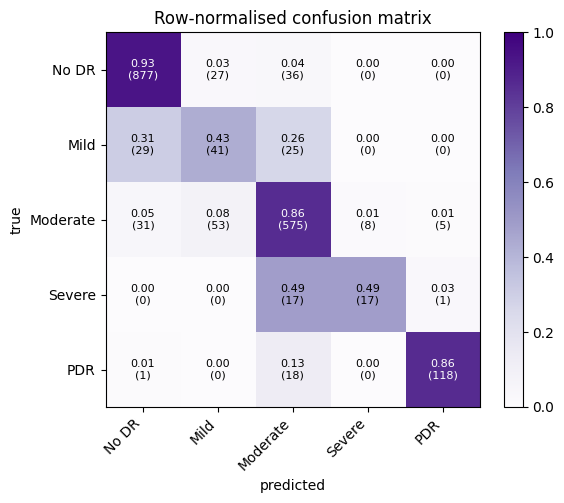

total errors: 251 | off by one stage: 160 | off by two or more: 91


In [59]:
confusion_counts = np.array(ddr_test_results['confusion_matrix'])
confusion_normalised = confusion_counts / confusion_counts.sum(axis=1, keepdims=True).clip(min=1)
short_names = ['No DR', 'Mild', 'Moderate', 'Severe', 'PDR']

show_table('Confusion matrix (rows = true, columns = predicted)',
           pd.DataFrame(confusion_counts, index=[f'true {n}' for n in short_names],
                        columns=[f'pred {n}' for n in short_names]))

fig, ax = plt.subplots(figsize=(6, 5))
image = ax.imshow(confusion_normalised, cmap='Purples', vmin=0, vmax=1)
ax.set_xticks(range(5)); ax.set_xticklabels(short_names, rotation=45, ha='right')
ax.set_yticks(range(5)); ax.set_yticklabels(short_names)
ax.set_xlabel('predicted'); ax.set_ylabel('true')
for i in range(5):
    for j in range(5):
        ax.text(j, i, f'{confusion_normalised[i, j]:.2f}\n({confusion_counts[i, j]})', ha='center', va='center',
                fontsize=8, color='white' if confusion_normalised[i, j] > 0.5 else 'black')
ax.set_title('Row-normalised confusion matrix')
plt.colorbar(image)
save_figure('results/figures/fig10_confusion_matrix.png')

adjacent_errors = sum(confusion_counts[i, j] for i in range(5) for j in range(5) if abs(i - j) == 1)
far_errors = sum(confusion_counts[i, j] for i in range(5) for j in range(5) if abs(i - j) >= 2)
total_errors = confusion_counts.sum() - np.trace(confusion_counts)
print(f'total errors: {total_errors} | off by one stage: {adjacent_errors} | off by two or more: {far_errors}')

### 6.9 ROC curve for referable DR
Uses the continuous severity score, with operating points at 90% and 95% specificity. The red line marks the common screening target of 80% sensitivity at 95% specificity.

figure saved: results/figures/fig11_referable_roc.png


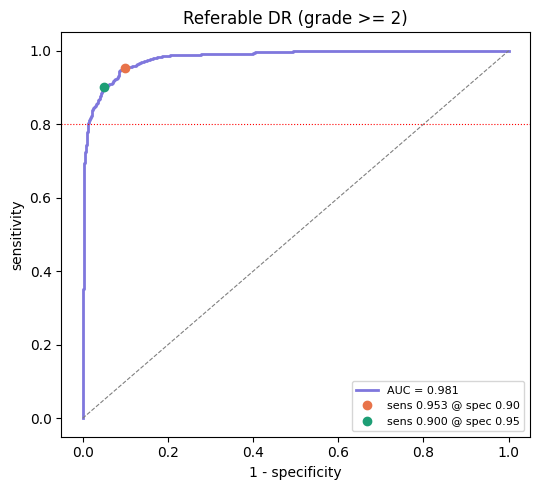

referable DR AUC: 0.9807 | prevalence 44.9%
at 90.1% specificity -> sensitivity 95.3%
at 95.1% specificity -> sensitivity 90.0%


In [60]:
is_referable = (ddr_test_true_grades >= 2).astype(int)
false_positive_rate, true_positive_rate, _ = roc_curve(is_referable, ddr_test_predictions['expected_grade'])
referable_results = ddr_test_results['referable']

fig, ax = plt.subplots(figsize=(5.5, 5))
ax.plot(false_positive_rate, true_positive_rate, color='#7F77DD', lw=2, label=f"AUC = {referable_results['auc']:.3f}")
ax.plot([0, 1], [0, 1], ls='--', lw=0.8, color='grey')
for specificity, colour in [(90, '#E8734A'), (95, '#1D9E75')]:
    point = referable_results[f'sens_at_spec_{specificity}']
    ax.plot(1 - point['specificity'], point['sensitivity'], 'o', color=colour,
            label=f"sens {point['sensitivity']:.3f} @ spec {point['specificity']:.2f}")
ax.axhline(0.80, ls=':', lw=0.8, color='red')
ax.set_xlabel('1 - specificity'); ax.set_ylabel('sensitivity')
ax.set_title('Referable DR (grade >= 2)'); ax.legend(loc='lower right', fontsize=8)
save_figure('results/figures/fig11_referable_roc.png')

print(f"referable DR AUC: {referable_results['auc']:.4f} | prevalence {referable_results['prevalence']:.1%}")
for specificity in (90, 95):
    point = referable_results[f'sens_at_spec_{specificity}']
    print(f"at {point['specificity']:.1%} specificity -> sensitivity {point['sensitivity']:.1%}")

### 6.10 Calibration
Checks whether the model's confidence matches its real accuracy. A well-calibrated model lies on the diagonal; ECE is the average gap.

figure saved: results/figures/fig12_calibration.png


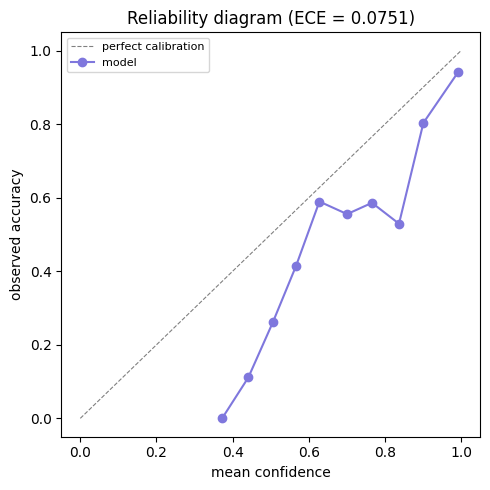

expected calibration error (ECE): 0.0751
maximum calibration error (MCE) : 0.3726


In [61]:
calibration = ddr_test_results['calibration']
calibration_bins = pd.DataFrame(calibration['bins'])

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot([0, 1], [0, 1], ls='--', color='grey', lw=0.8, label='perfect calibration')
ax.plot(calibration_bins['confidence'], calibration_bins['accuracy'], 'o-', color='#7F77DD', label='model')
ax.set_xlabel('mean confidence'); ax.set_ylabel('observed accuracy')
ax.set_title(f"Reliability diagram (ECE = {calibration['ece']:.4f})")
ax.legend(fontsize=8)
save_figure('results/figures/fig12_calibration.png')

print(f"expected calibration error (ECE): {calibration['ece']:.4f}")
print(f"maximum calibration error (MCE) : {calibration['mce']:.4f}")

### 6.11 Risk-coverage: does uncertainty find the mistakes?
The model grades only its most certain cases and passes the rest to a human. If uncertainty is useful, accuracy rises as coverage falls.

figure saved: results/figures/fig13_risk_coverage.png


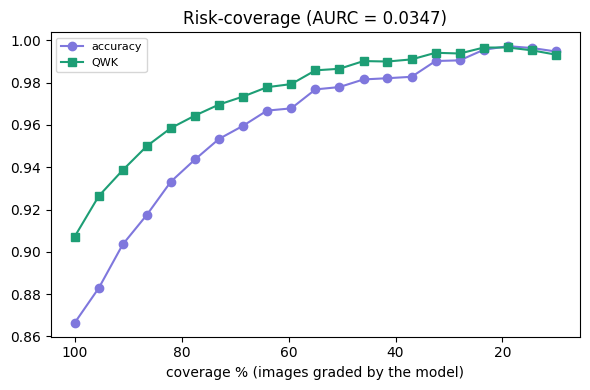

accuracy grading 100% of images: 0.8664
accuracy grading  80% of images: 0.9437
accuracy grading  50% of images: 0.9815


In [62]:
selective = ddr_test_results['selective']
coverage_points = pd.DataFrame(selective['points'])

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(coverage_points['coverage'] * 100, coverage_points['accuracy'], 'o-', color='#7F77DD', label='accuracy')
ax.plot(coverage_points['coverage'] * 100, coverage_points['qwk'], 's-', color='#1D9E75', label='QWK')
ax.invert_xaxis()
ax.set_xlabel('coverage % (images graded by the model)')
ax.set_title(f"Risk-coverage (AURC = {selective['aurc']:.4f})")
ax.legend(fontsize=8)
save_figure('results/figures/fig13_risk_coverage.png')

print(f"accuracy grading 100% of images: {coverage_points['accuracy'].iloc[0]:.4f}")
print(f"accuracy grading  80% of images: {coverage_points[coverage_points.coverage <= 0.8]['accuracy'].iloc[0]:.4f}")
print(f"accuracy grading  50% of images: {coverage_points[coverage_points.coverage <= 0.5]['accuracy'].iloc[0]:.4f}")

### 6.12 Referral threshold sweep
For each share of images passed to a human, shows the accuracy and the referable-DR sensitivity on the images the model keeps. Deferring uncertain cases must not remove the sick patients.

In [63]:
referral_sweep = pd.DataFrame(sweep_referral_thresholds(ddr_test_predictions['uncertainty'],
                                                        ddr_test_true_grades, ddr_test_predictions['grade']))
referral_sweep.to_csv('results/tables/table9_referral_sweep.csv', index=False)
show_table('Deferral rate vs accuracy and sensitivity on kept images', referral_sweep.round(4))


=== Deferral rate vs accuracy and sensitivity on kept images ===
   deferred_%  uncertainty_cutoff  images_kept  accuracy_on_kept  referable_sensitivity_on_kept
0           0              0.4749         1879            0.8664                         0.8993
1           5              0.1637         1785            0.8846                         0.9097
2          10              0.1131         1691            0.9054                         0.9266
3          20              0.0508         1503            0.9415                         0.9643
4          30              0.0192         1315            0.9582                         0.9755


### 6.13 Triage decisions on the full test split (including ungradable images)
Applies the four-step triage policy to every test image. Ungradable photos should mostly be sent for re-capture.

In [64]:
triage_decisions = pd.DataFrame([make_triage_decision(test_all_predictions, i, config)
                                 for i in range(len(ddr_test_all))])
triage_decisions['true_label'] = ddr_test_all['raw_label'].map(LABEL_NAMES).values

triage_table = pd.crosstab(triage_decisions['true_label'], triage_decisions['action'])
triage_table = triage_table.reindex([name for name in LABEL_NAMES.values() if name in triage_table.index])
triage_table.to_csv('results/tables/table9b_triage_actions.csv')
show_table('Share of each triage action', triage_decisions['action'].value_counts(normalize=True).round(3).to_frame('share'))
show_table('True label vs triage action', triage_table)


=== Share of each triage action ===
                         share
action                        
Routine rescreen         0.546
Refer to ophthalmology   0.430
Refer for human grading  0.024

=== True label vs triage action ===
action            Refer for human grading  Refer to ophthalmology  Routine rescreen
true_label                                                                         
No DR                                  17                      36               887
Mild NPDR                               7                      23                65
Moderate NPDR                          20                     580                72
Severe NPDR                             0                      35                 0
Proliferative DR                        2                     134                 1


### 6.14 External validation on APTOS 2019
The same model on a dataset from a different country, population and cameras. A drop in performance here shows the effect of this distribution shift.

In [65]:
aptos_predictions, aptos_true_grades = predict_images(aptos_images, 'APTOS external')
aptos_results = full_evaluation(aptos_true_grades, aptos_predictions['grade'], aptos_predictions['expected_grade'],
                                uncertainty=aptos_predictions['uncertainty'], confidences=aptos_predictions['confidence'])

metric_rows = {
    'accuracy': 'accuracy', 'macro precision': 'macro_precision', 'macro recall': 'macro_recall',
    'macro F1-score': 'macro_f1', 'weighted F1-score': 'weighted_f1', 'quadratic kappa': 'qwk'}
external_comparison = pd.DataFrame({
    'DDR test (internal)': [ddr_test_results[key] for key in metric_rows.values()] + [ddr_test_results['referable']['auc']],
    'APTOS (external)': [aptos_results[key] for key in metric_rows.values()] + [aptos_results['referable']['auc']],
}, index=list(metric_rows.keys()) + ['referable DR AUC']).round(4)
external_comparison['difference'] = (external_comparison.iloc[:, 0] - external_comparison.iloc[:, 1]).round(4)
external_comparison.to_csv('results/tables/table10_external_validation.csv')
show_table('Internal vs external results', external_comparison)

print('\nAPTOS per-stage report:')
print(classification_report(aptos_true_grades, aptos_predictions['grade'], labels=list(range(5)),
                            target_names=[GRADE_NAMES[g] for g in range(5)], digits=3, zero_division=0))
print_binary_report('APTOS DR detection: any DR vs No DR', aptos_results['dr_detection'])

  0%|          | 0/115 [00:00<?, ?it/s]

[APTOS external] 3662 images predicted in 40s

=== Internal vs external results ===
                   DDR test (internal)  APTOS (external)  difference
accuracy                        0.8664            0.7018      0.1646
macro precision                 0.7525            0.5410      0.2115
macro recall                    0.7134            0.4535      0.2599
macro F1-score                  0.7282            0.4556      0.2726
weighted F1-score               0.8692            0.6824      0.1868
quadratic kappa                 0.9072            0.7921      0.1151
referable DR AUC                0.9807            0.9640      0.0167

APTOS per-stage report:
                  precision    recall  f1-score   support

           No DR      1.000     0.822     0.902      1805
       Mild NPDR      0.119     0.059     0.079       370
   Moderate NPDR      0.530     0.951     0.681       999
     Severe NPDR      0.360     0.140     0.201       193
Proliferative DR      0.696     0.295     0.414 

### 6.15 Save all metrics

In [66]:
with open('results/logs/evaluation.json', 'w') as file:
    json.dump({'ddr_test': ddr_test_results, 'aptos_external': aptos_results, 'config': config.to_dict()},
              file, indent=2, default=float)
print('all metrics saved to results/logs/evaluation.json')

all metrics saved to results/logs/evaluation.json


### 6.16 Largest errors
The six test images with the biggest grade error, with the model's confidence and uncertainty. Useful for error analysis (e.g. poor image quality, subtle lesions, label noise).

figure saved: results/figures/fig14_error_gallery.png


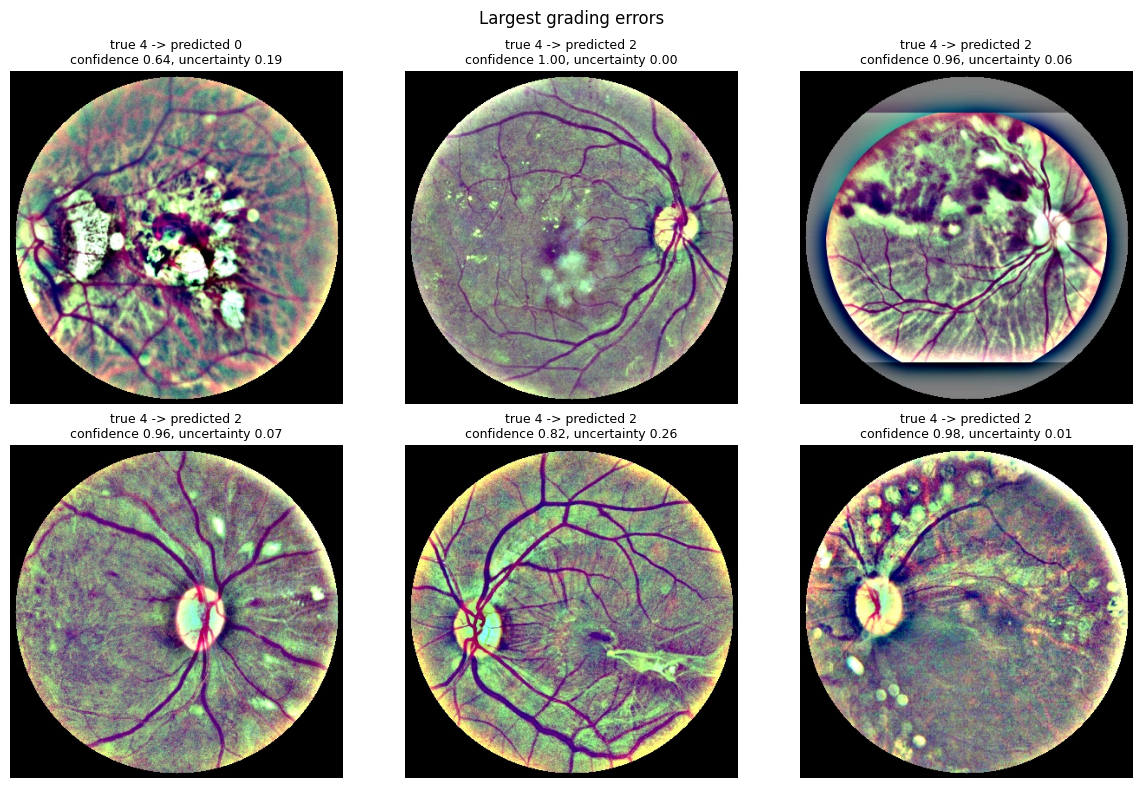


=== Largest errors ===
                                    image  true_grade  predicted_grade  confidence  uncertainty
0  DR_grading/DR_grading/007-7160-400.jpg           4                0       0.639        0.188
1  DR_grading/DR_grading/007-6765-400.jpg           4                2       0.999        0.002
2  DR_grading/DR_grading/007-6632-400.jpg           4                2       0.958        0.062
3  DR_grading/DR_grading/007-6676-400.jpg           4                2       0.955        0.069
4  DR_grading/DR_grading/007-6331-400.jpg           4                2       0.815        0.259
5  DR_grading/DR_grading/007-6316-400.jpg           4                2       0.985        0.009


In [67]:
grade_errors = np.abs(ddr_test_true_grades - ddr_test_predictions['grade'])
worst_indices = np.argsort(-grade_errors)[:6]

error_rows = []
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for ax in axes.ravel():
    ax.axis('off')
for ax, index in zip(axes.ravel(), worst_indices):
    image = cv2.imread(ddr_test_set.loc[index, 'cached'])
    ax.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    ax.set_title(f"true {ddr_test_true_grades[index]} -> predicted {ddr_test_predictions['grade'][index]}\n"
                 f"confidence {ddr_test_predictions['confidence'][index]:.2f}, "
                 f"uncertainty {ddr_test_predictions['uncertainty'][index]:.2f}", fontsize=9)
    error_rows.append({'image': ddr_test_set.loc[index, 'image'],
                       'true_grade': int(ddr_test_true_grades[index]),
                       'predicted_grade': int(ddr_test_predictions['grade'][index]),
                       'confidence': round(float(ddr_test_predictions['confidence'][index]), 3),
                       'uncertainty': round(float(ddr_test_predictions['uncertainty'][index]), 3)})
plt.suptitle('Largest grading errors')
save_figure('results/figures/fig14_error_gallery.png', dpi=150)
show_table('Largest errors', pd.DataFrame(error_rows))

## 7. Explainability (Grad-CAM)

Grad-CAM shows which parts of the image pushed the predicted severity up. For DR, the heatmap should highlight lesions (haemorrhages, exudates, microaneurysms) rather than the optic disc or the image border.

A sanity check compares the trained model's heatmap with one from a randomly initialised network. If they looked the same, the heatmap would only reflect image edges, not what the model learned.

### 7.1 Grad-CAM functions

In [68]:
class GradCAM:
    # heatmap of the regions that increase the predicted severity

    def __init__(self, model, target_layer=None):
        self.model = model
        self.activations = None
        self.gradients = None
        layer = target_layer or self._last_conv_layer()
        self.hook_handle = layer.register_forward_hook(self._save_activations)

    def _last_conv_layer(self):
        last = None
        for module in self.model.backbone.modules():
            if isinstance(module, nn.Conv2d):
                last = module
        return last

    def _save_activations(self, module, inputs, output):
        self.activations = output.detach()
        if output.requires_grad:
            output.register_hook(self._save_gradients)

    def _save_gradients(self, gradient):
        self.gradients = gradient.detach()

    def remove(self):
        self.hook_handle.remove()

    def __call__(self, image_tensor):
        self.model.eval()
        self.model.zero_grad(set_to_none=True)
        with torch.enable_grad():
            grade_logits, _ = self.model(image_tensor)
            corn_expected_grade(grade_logits.float()).sum().backward()
        channel_weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        heatmap = F.relu((channel_weights * self.activations).sum(dim=1, keepdim=True))
        heatmap = F.interpolate(heatmap, size=image_tensor.shape[-2:], mode='bilinear', align_corners=False)
        heatmap = heatmap[0, 0].cpu().numpy()
        if heatmap.max() > heatmap.min():
            heatmap = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min())
        return heatmap


def overlay_heatmap(image_bgr, heatmap, alpha=0.4):
    heatmap = cv2.resize(heatmap.astype(np.float32), (image_bgr.shape[1], image_bgr.shape[0]))
    coloured = cv2.applyColorMap(np.uint8(255 * heatmap), cv2.COLORMAP_JET)
    return cv2.addWeighted(coloured, alpha, image_bgr, 1 - alpha, 0)


def image_to_tensor(image_bgr):
    return eval_transform(cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB))[None].to(config.device)

### 7.2 Grad-CAM for one test image per grade

figure saved: results/figures/fig15_gradcam_by_grade.png


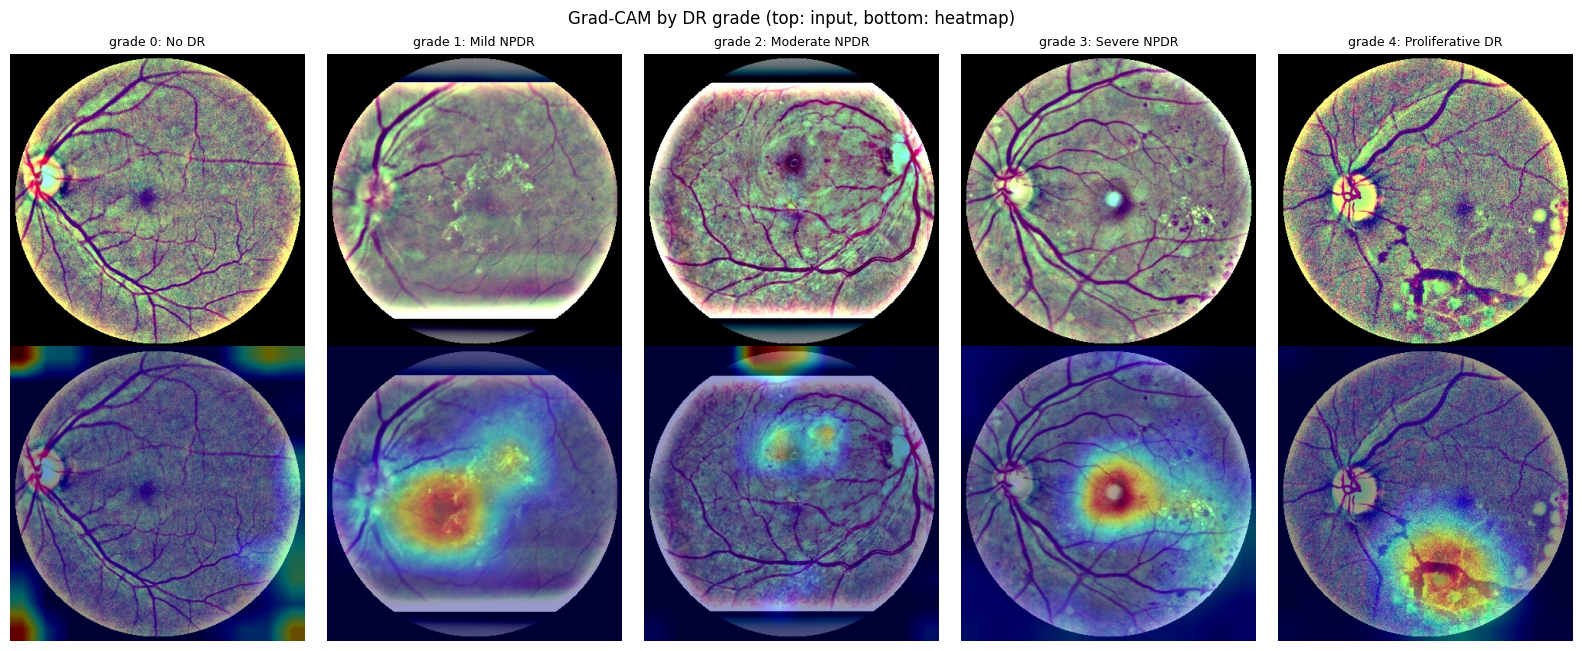

In [69]:
gradcam = GradCAM(evaluation_model)

fig, axes = plt.subplots(2, 5, figsize=(16, 6.6))
for ax in axes.ravel():
    ax.axis('off')
for column, grade in enumerate(range(5)):
    candidates = ddr_test_set[ddr_test_set['level'] == grade]
    if len(candidates) == 0:
        continue
    preprocessed_image = cv2.imread(candidates.sample(1, random_state=RANDOM_SEED).iloc[0]['cached'])
    heatmap = gradcam(image_to_tensor(preprocessed_image))
    axes[0, column].imshow(cv2.cvtColor(preprocessed_image, cv2.COLOR_BGR2RGB))
    axes[0, column].set_title(f'grade {grade}: {GRADE_NAMES[grade]}', fontsize=9)
    axes[1, column].imshow(cv2.cvtColor(overlay_heatmap(preprocessed_image, heatmap), cv2.COLOR_BGR2RGB))
plt.suptitle('Grad-CAM by DR grade (top: input, bottom: heatmap)')
save_figure('results/figures/fig15_gradcam_by_grade.png', dpi=150)

### 7.3 Sanity check: trained model vs random weights
A low correlation between the two heatmaps means the trained heatmap reflects learned features.

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


figure saved: results/figures/fig15b_saliency_sanity_check.png


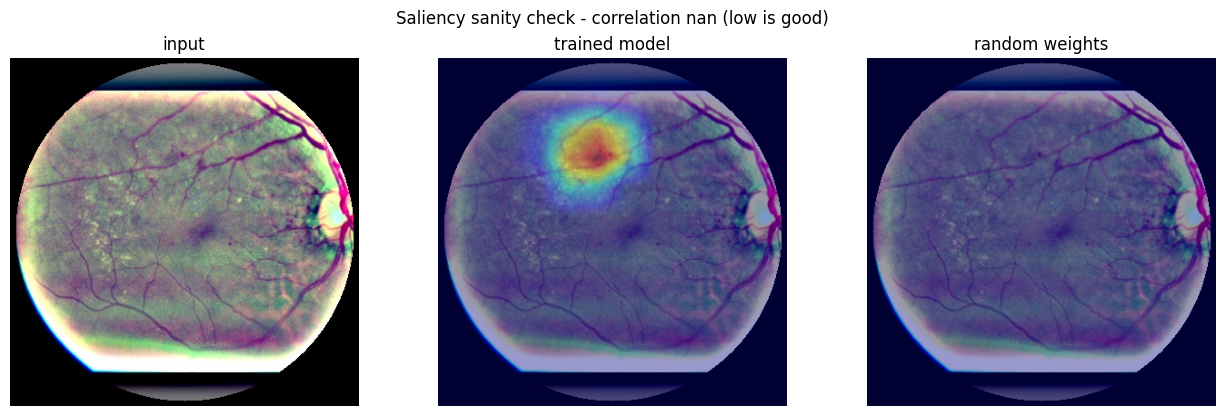

correlation between trained and random heatmaps: nan


In [70]:
random_model = build_model(config, pretrained=False).to(config.device)
random_gradcam = GradCAM(random_model)

referable_candidates = ddr_test_set[ddr_test_set['level'] >= 2]
preprocessed_image = cv2.imread(referable_candidates.sample(1, random_state=RANDOM_SEED).iloc[0]['cached'])
image_tensor = image_to_tensor(preprocessed_image)

trained_heatmap, random_heatmap = gradcam(image_tensor), random_gradcam(image_tensor)
map_correlation = float(np.corrcoef(trained_heatmap.ravel(), random_heatmap.ravel())[0, 1])

fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))
panels = [('input', cv2.cvtColor(preprocessed_image, cv2.COLOR_BGR2RGB)),
          ('trained model', cv2.cvtColor(overlay_heatmap(preprocessed_image, trained_heatmap), cv2.COLOR_BGR2RGB)),
          ('random weights', cv2.cvtColor(overlay_heatmap(preprocessed_image, random_heatmap), cv2.COLOR_BGR2RGB))]
for ax, (title, panel) in zip(axes, panels):
    ax.imshow(panel); ax.set_title(title); ax.axis('off')
plt.suptitle(f'Saliency sanity check - correlation {map_correlation:.3f} (low is good)')
save_figure('results/figures/fig15b_saliency_sanity_check.png', dpi=150)
print(f'correlation between trained and random heatmaps: {map_correlation:.3f}')

gradcam.remove(); random_gradcam.remove()
del random_model
if config.device == 'cuda':
    torch.cuda.empty_cache()

## 8. Export for CPU deployment

The prototype app runs on a laptop without a GPU. The backbone is exported to **ONNX** (plus a smaller **int8** version), and the two small heads are saved as NumPy arrays so the app can still run MC dropout for uncertainty. The export is checked numerically against PyTorch and timed on CPU.

### 8.1 Export functions

In [71]:
class BackboneOnly(nn.Module):
    # ONNX graph = backbone features only

    def __init__(self, network):
        super().__init__()
        self.network = network

    def forward(self, images):
        return self.network.forward_features(images)


def export_backbone_onnx(model, path, image_size=384, opset=17):
    model.eval()
    extra_options = {}
    if 'dynamo' in inspect.signature(torch.onnx.export).parameters:
        extra_options['dynamo'] = False
    torch.onnx.export(BackboneOnly(model), torch.randn(1, 3, image_size, image_size), path,
                      input_names=['image'], output_names=['features'],
                      dynamic_axes={'image': {0: 'batch'}, 'features': {0: 'batch'}},
                      opset_version=opset, do_constant_folding=True, **extra_options)
    print(f'[onnx] {path} ({Path(path).stat().st_size / 1e6:.1f} MB)')
    return path


def export_head_weights(model, path):
    np.savez(path,
             grade_w=model.grade_head.weight.detach().cpu().numpy(),
             grade_b=model.grade_head.bias.detach().cpu().numpy(),
             quality_w=model.quality_head.weight.detach().cpu().numpy(),
             quality_b=model.quality_head.bias.detach().cpu().numpy(),
             dropout_p=np.array(model.dropout.p, dtype=np.float32))
    print(f'[heads] {path}')
    return path


def quantize_int8(source_path, target_path):
    try:
        from onnxruntime.quantization import QuantType, quantize_dynamic
        quantize_dynamic(source_path, target_path, weight_type=QuantType.QUInt8)
    except Exception as error:
        print('[int8] skipped:', error)
        return None
    print(f'[int8] {Path(source_path).stat().st_size / 1e6:.1f} MB -> {Path(target_path).stat().st_size / 1e6:.1f} MB')
    return target_path


def benchmark_cpu(path, image_size=384, warmup_runs=3, timed_runs=20):
    import onnxruntime as ort
    try:
        session = ort.InferenceSession(path, providers=['CPUExecutionProvider'])
    except Exception as error:
        print(f'[benchmark] {Path(path).name} skipped:', error)
        return None
    input_name = session.get_inputs()[0].name
    dummy_image = np.random.randn(1, 3, image_size, image_size).astype(np.float32)
    for _ in range(warmup_runs):
        session.run(None, {input_name: dummy_image})
    times_ms = []
    for _ in range(timed_runs):
        start_time = time.perf_counter()
        session.run(None, {input_name: dummy_image})
        times_ms.append((time.perf_counter() - start_time) * 1000)
    times_ms = np.array(times_ms)
    return {'model': Path(path).name, 'median_ms': round(float(np.median(times_ms)), 1),
            'mean_ms': round(float(times_ms.mean()), 1), 'p95_ms': round(float(np.percentile(times_ms, 95)), 1),
            'size_mb': round(Path(path).stat().st_size / 1e6, 1)}


def verify_export(model, path, image_size=384, sample_count=4, tolerance=1e-3):
    # ONNX features must match PyTorch features
    import onnxruntime as ort
    model.eval()
    test_batch = torch.randn(sample_count, 3, image_size, image_size)
    with torch.no_grad():
        pytorch_features = model.forward_features(test_batch).numpy()
    session = ort.InferenceSession(path, providers=['CPUExecutionProvider'])
    onnx_features = session.run(None, {session.get_inputs()[0].name: test_batch.numpy()})[0]
    difference = np.abs(pytorch_features - onnx_features)
    return {'max_abs_diff': float(difference.max()), 'mean_abs_diff': float(difference.mean()),
            'verified': bool(difference.max() < tolerance), 'tolerance': tolerance}


def export_all(model, output_folder, image_size=384):
    output_folder = Path(output_folder)
    output_folder.mkdir(parents=True, exist_ok=True)
    fp32_path = export_backbone_onnx(model, str(output_folder / 'backbone_fp32.onnx'), image_size)
    export_head_weights(model, str(output_folder / 'heads.npz'))
    int8_path = quantize_int8(fp32_path, str(output_folder / 'backbone_int8.onnx'))
    benchmarks = [benchmark_cpu(path, image_size) for path in (fp32_path, int8_path) if path]
    manifest = {'image_size': image_size,
                'backbone': config.backbone,
                'verification': verify_export(model, fp32_path, image_size),
                'benchmarks': [b for b in benchmarks if b]}
    (output_folder / 'deployment_manifest.json').write_text(json.dumps(manifest, indent=2))
    return manifest

### 8.2 Export the best model

In [72]:
export_model = build_model(config, pretrained=False)
export_model.load_state_dict({name: weights.cpu() for name, weights in best_weights.items()})
export_model.eval()

deployment_manifest = export_all(export_model, 'models/export', config.image_size)

/tmp/ipykernel_23/2071608395.py:17: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(BackboneOnly(model), torch.randn(1, 3, image_size, image_size), path,


[onnx] models/export/backbone_fp32.onnx (80.6 MB)
[heads] models/export/heads.npz


  elem_type: 7
  shape {
    dim {
      dim_param: "unk__3"
    }
    dim {
      dim_value: 2
    }
  }
}
.
  elem_type: 7
  shape {
    dim {
      dim_param: "unk__22"
    }
    dim {
      dim_value: 2
    }
  }
}
.
  elem_type: 7
  shape {
    dim {
      dim_param: "unk__53"
    }
    dim {
      dim_value: 2
    }
  }
}
.
  elem_type: 7
  shape {
    dim {
      dim_param: "unk__86"
    }
    dim {
      dim_value: 2
    }
  }
}
.
  elem_type: 7
  shape {
    dim {
      dim_param: "unk__211"
    }
    dim {
      dim_value: 2
    }
  }
}
.


[int8] 80.6 MB -> 21.1 MB


### 8.3 Verification and CPU speed

In [73]:
verification = deployment_manifest['verification']
print(f"export verified: {verification['verified']} | max difference {verification['max_abs_diff']:.2e} "
      f"(tolerance {verification['tolerance']})")
show_table('CPU latency per image', pd.DataFrame(deployment_manifest['benchmarks']))

export verified: True | max difference 5.25e-06 (tolerance 0.001)

=== CPU latency per image ===
                model  median_ms  mean_ms  p95_ms  size_mb
0  backbone_fp32.onnx      186.2    187.1   197.7     80.6
1  backbone_int8.onnx      343.1    341.5   350.7     21.1


### 8.4 Package the results for download
`dr_triage_artifacts.zip` contains the exported model, all figures, tables and logs.

In [74]:
artifacts_zip = WORKING_DIR / 'dr_triage_artifacts.zip'
with zipfile.ZipFile(artifacts_zip, 'w', zipfile.ZIP_DEFLATED) as archive:
    for folder in ['models/export', 'results']:
        for path in sorted(Path(folder).rglob('*')):
            if path.is_file():
                archive.write(path, path.as_posix())
print(f'{artifacts_zip} ({artifacts_zip.stat().st_size / 1e6:.1f} MB)')

/kaggle/working/dr_triage_artifacts.zip (104.3 MB)


## 9. Summary of results

In [75]:
ddr_detection = ddr_test_results['dr_detection']
print('=' * 70)
print('DATA')
print(f"  DDR         {len(ddr_images)} images ({int(ddr_images.ungradable.sum())} ungradable) | "
      f"split: {ddr_images['split_source'].iloc[0]}")
print(f"  APTOS 2019  {len(aptos_images)} images (external test only)")
print('MODEL')
print(f'  {config.backbone} | {len(history_table)} / {config.epochs} epochs | '
      f'best validation QWK {history_table.val_qwk.max():.4f}')
print('DDR TEST - 5-stage classification')
print(f"  accuracy {ddr_test_results['accuracy']:.4f} | macro precision {ddr_test_results['macro_precision']:.4f} | "
      f"macro recall {ddr_test_results['macro_recall']:.4f} | macro F1 {ddr_test_results['macro_f1']:.4f} | "
      f"QWK {ddr_test_results['qwk']:.4f}")
print('DDR TEST - DR detection (any DR vs No DR)')
print(f"  accuracy {ddr_detection['accuracy']:.4f} | precision {ddr_detection['precision']:.4f} | "
      f"recall {ddr_detection['recall_sensitivity']:.4f} | F1 {ddr_detection['f1']:.4f}")
print('DDR TEST - referable DR')
print(f"  AUC {ddr_test_results['referable']['auc']:.4f} | "
      f"sensitivity at 95% specificity {ddr_test_results['referable']['sens_at_spec_95']['sensitivity']:.4f}")
print('APTOS EXTERNAL')
print(f"  accuracy {aptos_results['accuracy']:.4f} | macro F1 {aptos_results['macro_f1']:.4f} | "
      f"QWK {aptos_results['qwk']:.4f} | referable AUC {aptos_results['referable']['auc']:.4f}")
print('UNCERTAINTY')
print(f"  calibration ECE {ddr_test_results['calibration']['ece']:.4f} | "
      f"risk-coverage AURC {ddr_test_results['selective']['aurc']:.4f}")
print('DEPLOYMENT')
print(f"  ONNX export verified: {deployment_manifest['verification']['verified']}")
print('=' * 70)

DATA
  DDR         12522 images (0 ungradable) | split: generated
  APTOS 2019  3662 images (external test only)
MODEL
  tf_efficientnetv2_s.in21k_ft_in1k | 20 / 25 epochs | best validation QWK 0.8960
DDR TEST - 5-stage classification
  accuracy 0.8664 | macro precision 0.7525 | macro recall 0.7134 | macro F1 0.7282 | QWK 0.9072
DDR TEST - DR detection (any DR vs No DR)
  accuracy 0.9340 | precision 0.9330 | recall 0.9350 | F1 0.9340
DDR TEST - referable DR
  AUC 0.9807 | sensitivity at 95% specificity 0.9005
APTOS EXTERNAL
  accuracy 0.7018 | macro F1 0.4556 | QWK 0.7921 | referable AUC 0.9640
UNCERTAINTY
  calibration ECE 0.0751 | risk-coverage AURC 0.0347
DEPLOYMENT
  ONNX export verified: True
